In [1]:
# ===== CELL 1: Import Libraries =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'


In [2]:
# ===== CELL 2: Load Data =====
df = pd.read_csv('china_cancer_patients_synthetic.csv')

print("📊 Thông tin dữ liệu:")
print(f"Kích thước: {df.shape}")
print(f"\nCác cột:\n{df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum().sum()} total")


📊 Thông tin dữ liệu:
Kích thước: (10000, 20)

Các cột:
['PatientID', 'Gender', 'Age', 'Province', 'Ethnicity', 'TumorType', 'CancerStage', 'DiagnosisDate', 'TumorSize', 'Metastasis', 'TreatmentType', 'SurgeryDate', 'ChemotherapySessions', 'RadiationSessions', 'SurvivalStatus', 'FollowUpMonths', 'SmokingStatus', 'AlcoholUse', 'GeneticMutation', 'Comorbidities']

Missing values:
22509 total


✅ Đã lưu biểu đồ: cancer_data_full_visualization.png


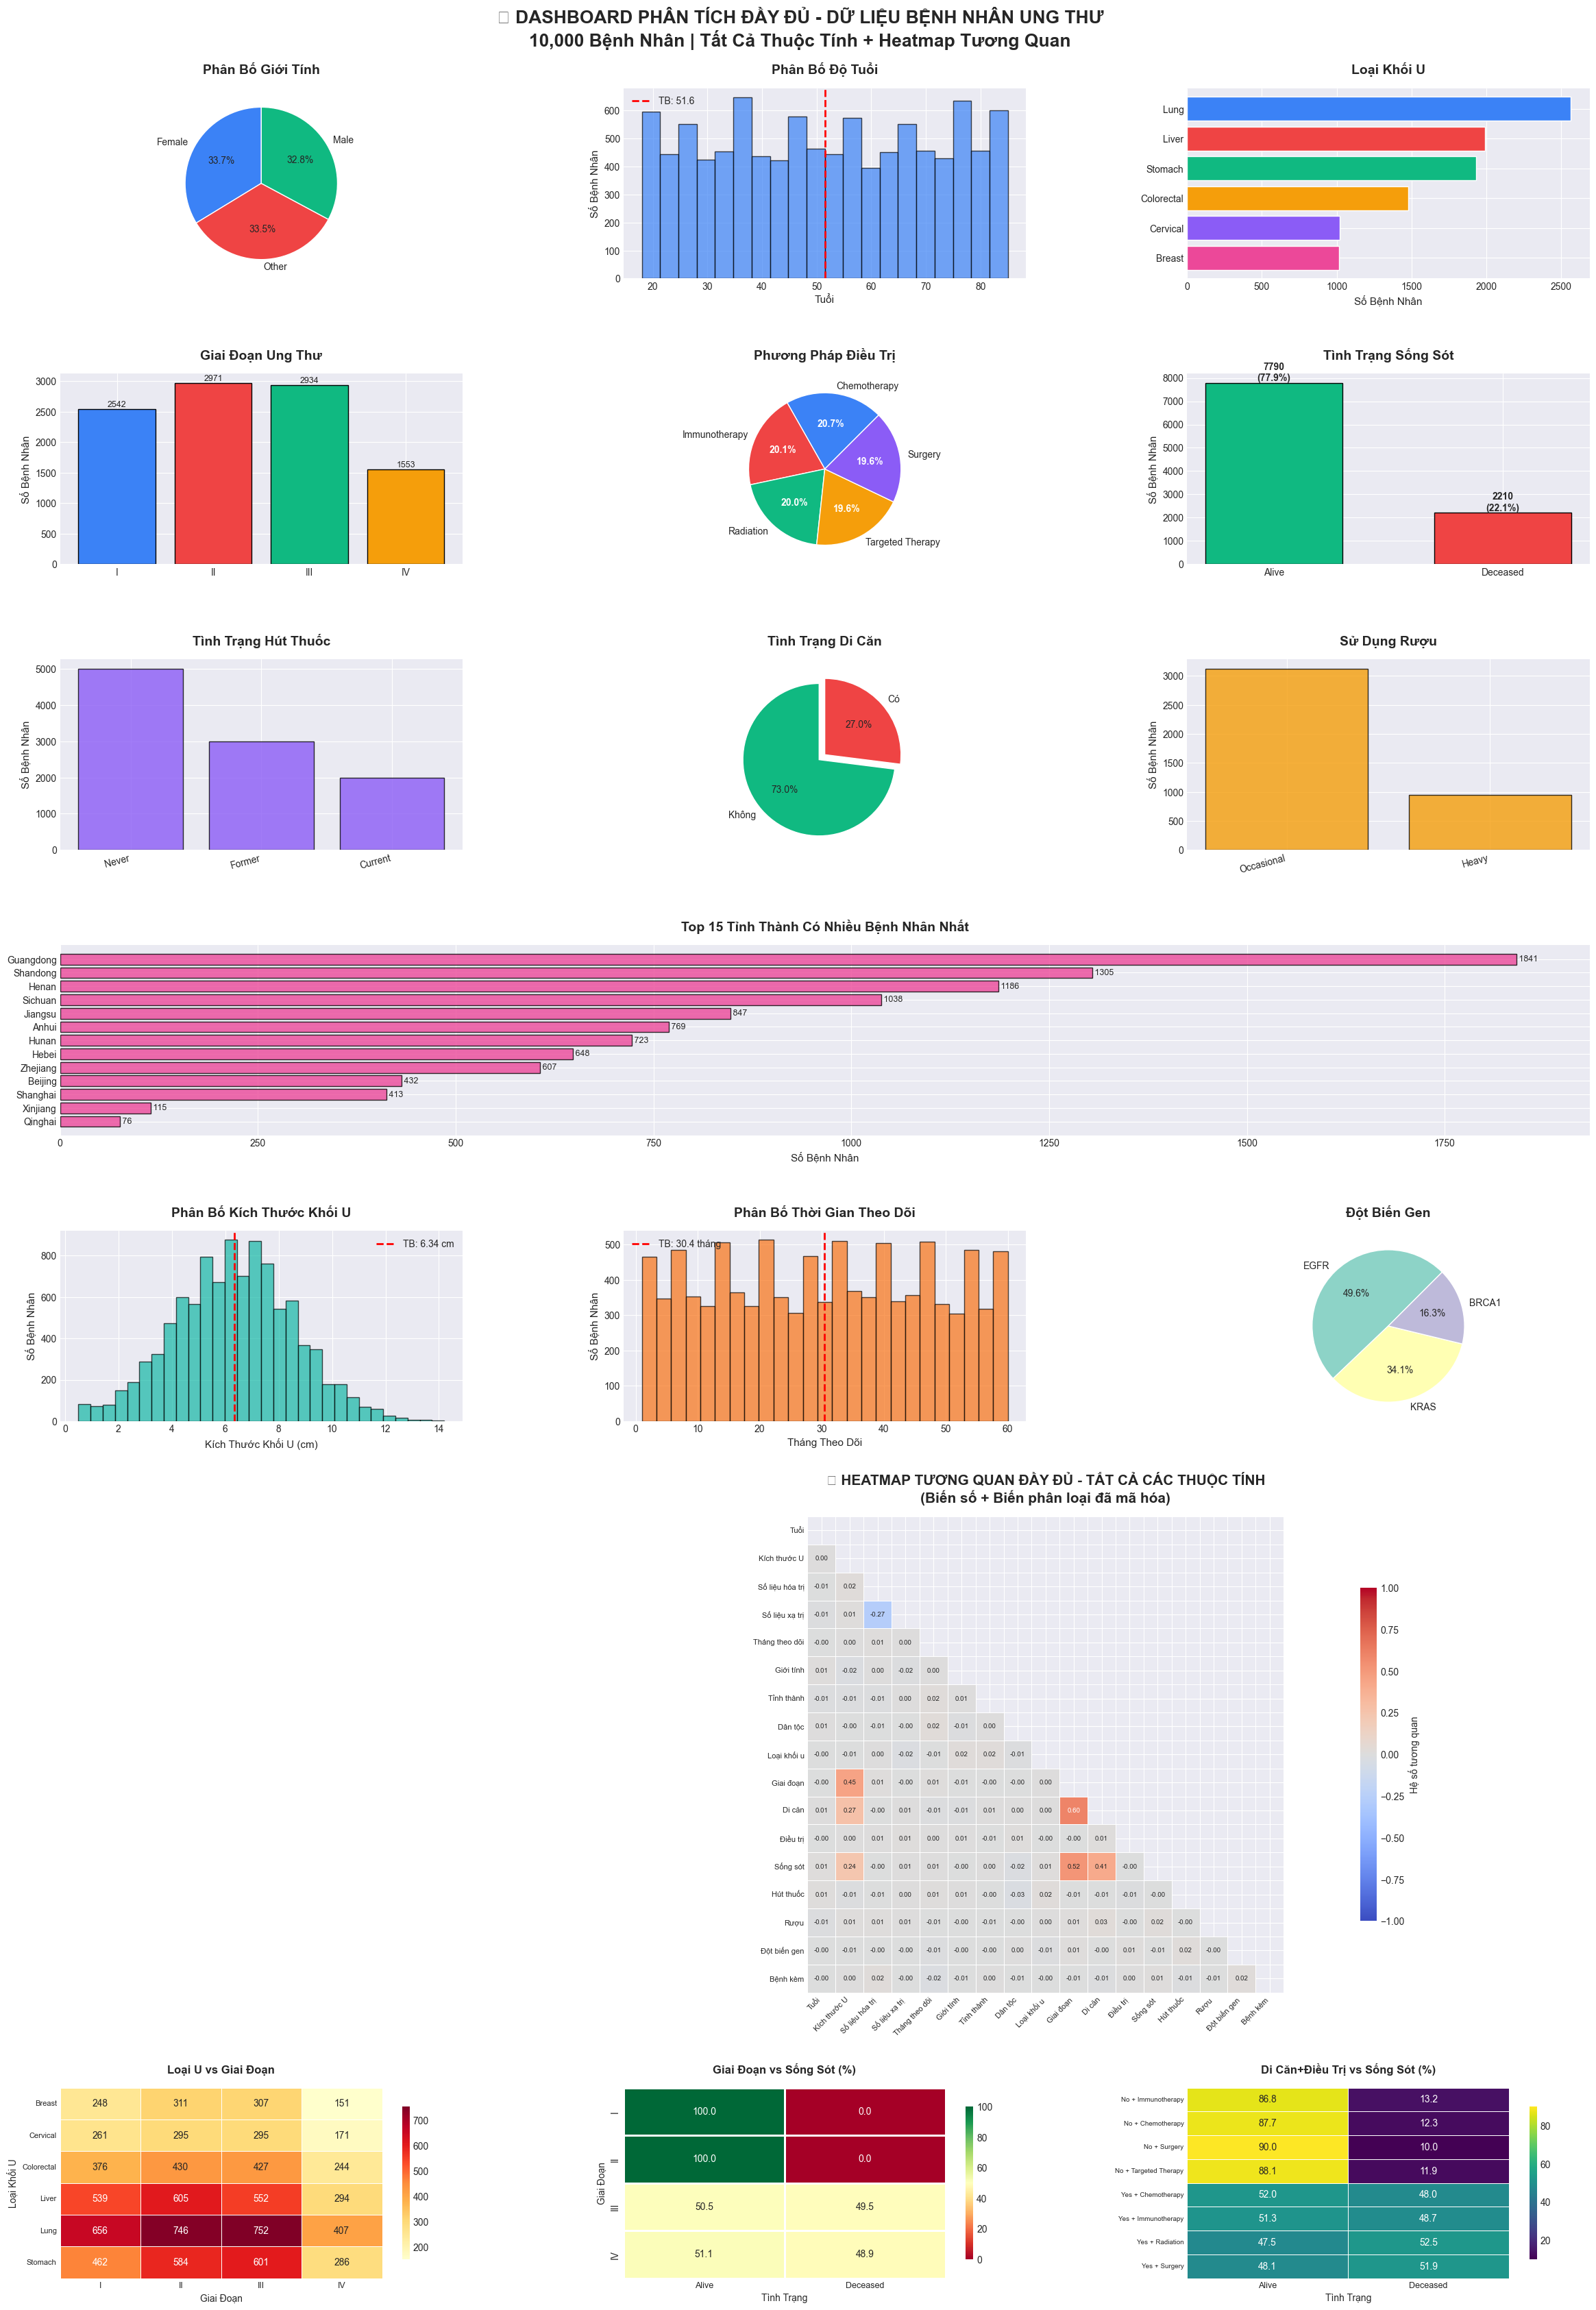


📊 THỐNG KÊ TỔNG QUAN CHI TIẾT
Tổng số bệnh nhân: 10,000

📈 Biến số:
  • Tuổi trung bình: 51.6 ± 19.7 (Min: 18, Max: 85)
  • Kích thước khối u TB: 6.34 ± 2.23 cm
  • Số liệu hóa trị TB: 4.0
  • Số liệu xạ trị TB: 3.0
  • Thời gian theo dõi TB: 30.4 tháng

🎯 Biến phân loại:
  • Tỷ lệ sống sót: 77.9%
  • Tỷ lệ di căn: 27.0%
  • Số loại khối u: 6
  • Số tỉnh thành: 13
  • Số dân tộc: 6

🔬 Tương quan mạnh nhất (Top 5):
  1. Giai đoạn ↔ Di căn: 0.596
  2. Di căn ↔ Giai đoạn: 0.596
  3. Giai đoạn ↔ Sống sót: 0.517
  4. Sống sót ↔ Giai đoạn: 0.517
  5. Kích thước U ↔ Giai đoạn: 0.450


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load data
df = pd.read_csv('china_cancer_patients_synthetic.csv')

# Create figure with GridSpec for better layout
fig = plt.figure(figsize=(24, 34))
gs = GridSpec(8, 3, figure=fig, hspace=0.5, wspace=0.4, top=0.96, bottom=0.02, left=0.05, right=0.98)

# Color palette
colors = ['#3B82F6', '#EF4444', '#10B981', '#F59E0B', '#8B5CF6', '#EC4899', '#14B8A6', '#F97316']

# ==================== ROW 1 ====================
# 1. Gender Distribution (Pie)
ax1 = fig.add_subplot(gs[0, 0])
gender_counts = df['Gender'].value_counts()
ax1.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
        colors=colors[:len(gender_counts)], startangle=90)
ax1.set_title('Phân Bố Giới Tính', fontsize=14, fontweight='bold', pad=15)

# 2. Age Distribution (Histogram)
ax2 = fig.add_subplot(gs[0, 1])
df['Age'].hist(bins=20, ax=ax2, color='#3B82F6', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Tuổi', fontsize=11)
ax2.set_ylabel('Số Bệnh Nhân', fontsize=11)
ax2.set_title('Phân Bố Độ Tuổi', fontsize=14, fontweight='bold', pad=15)
ax2.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'TB: {df["Age"].mean():.1f}')
ax2.legend()

# 3. Tumor Type Distribution
ax3 = fig.add_subplot(gs[0, 2])
tumor_counts = df['TumorType'].value_counts()
ax3.barh(range(len(tumor_counts)), tumor_counts.values, color=colors)
ax3.set_yticks(range(len(tumor_counts)))
ax3.set_yticklabels(tumor_counts.index, fontsize=10)
ax3.set_xlabel('Số Bệnh Nhân', fontsize=11)
ax3.set_title('Loại Khối U', fontsize=14, fontweight='bold', pad=15)
ax3.invert_yaxis()

# ==================== ROW 2 ====================
# 4. Cancer Stage Distribution
ax4 = fig.add_subplot(gs[1, 0])
stage_counts = df['CancerStage'].value_counts().sort_index()
bars = ax4.bar(range(len(stage_counts)), stage_counts.values, color=colors, edgecolor='black')
ax4.set_xticks(range(len(stage_counts)))
ax4.set_xticklabels(stage_counts.index)
ax4.set_ylabel('Số Bệnh Nhân', fontsize=11)
ax4.set_title('Giai Đoạn Ung Thư', fontsize=14, fontweight='bold', pad=15)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=9)

# 5. Treatment Type Distribution
ax5 = fig.add_subplot(gs[1, 1])
treatment_counts = df['TreatmentType'].value_counts()
wedges, texts, autotexts = ax5.pie(treatment_counts.values, labels=treatment_counts.index, 
                                     autopct='%1.1f%%', colors=colors[:len(treatment_counts)], 
                                     startangle=45)
ax5.set_title('Phương Pháp Điều Trị', fontsize=14, fontweight='bold', pad=15)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 6. Survival Status
ax6 = fig.add_subplot(gs[1, 2])
survival_counts = df['SurvivalStatus'].value_counts()
colors_survival = ['#10B981' if x == 'Alive' else '#EF4444' for x in survival_counts.index]
bars = ax6.bar(range(len(survival_counts)), survival_counts.values, color=colors_survival, 
               edgecolor='black', width=0.6)
ax6.set_xticks(range(len(survival_counts)))
ax6.set_xticklabels(survival_counts.index)
ax6.set_ylabel('Số Bệnh Nhân', fontsize=11)
ax6.set_title('Tình Trạng Sống Sót', fontsize=14, fontweight='bold', pad=15)
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(df)*100:.1f}%)', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# ==================== ROW 3 ====================
# 7. Smoking Status
ax7 = fig.add_subplot(gs[2, 0])
smoking_counts = df['SmokingStatus'].value_counts()
bars = ax7.bar(range(len(smoking_counts)), smoking_counts.values, color='#8B5CF6', 
               edgecolor='black', alpha=0.8)
ax7.set_xticks(range(len(smoking_counts)))
ax7.set_xticklabels(smoking_counts.index, rotation=15, ha='right')
ax7.set_ylabel('Số Bệnh Nhân', fontsize=11)
ax7.set_title('Tình Trạng Hút Thuốc', fontsize=14, fontweight='bold', pad=15)

# 8. Metastasis Status
ax8 = fig.add_subplot(gs[2, 1])
metastasis_counts = df['Metastasis'].value_counts()
colors_meta = ['#EF4444' if x == 'Yes' else '#10B981' for x in metastasis_counts.index]
explode = (0.1, 0)
ax8.pie(metastasis_counts.values, labels=['Có' if x=='Yes' else 'Không' for x in metastasis_counts.index], 
        autopct='%1.1f%%', colors=colors_meta, startangle=90, explode=explode)
ax8.set_title('Tình Trạng Di Căn', fontsize=14, fontweight='bold', pad=15)

# 9. Alcohol Use
ax9 = fig.add_subplot(gs[2, 2])
alcohol_counts = df['AlcoholUse'].value_counts()
bars = ax9.bar(range(len(alcohol_counts)), alcohol_counts.values, color='#F59E0B', 
               edgecolor='black', alpha=0.8)
ax9.set_xticks(range(len(alcohol_counts)))
ax9.set_xticklabels(alcohol_counts.index, rotation=15, ha='right')
ax9.set_ylabel('Số Bệnh Nhân', fontsize=11)
ax9.set_title('Sử Dụng Rượu', fontsize=14, fontweight='bold', pad=15)

# ==================== ROW 4 ====================
# 10. Top 15 Provinces
ax10 = fig.add_subplot(gs[3, :])
province_counts = df['Province'].value_counts().head(15)
bars = ax10.barh(range(len(province_counts)), province_counts.values, color='#EC4899', 
                 edgecolor='black', alpha=0.8)
ax10.set_yticks(range(len(province_counts)))
ax10.set_yticklabels(province_counts.index, fontsize=10)
ax10.set_xlabel('Số Bệnh Nhân', fontsize=11)
ax10.set_title('Top 15 Tỉnh Thành Có Nhiều Bệnh Nhân Nhất', fontsize=14, fontweight='bold', pad=15)
ax10.invert_yaxis()
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax10.text(width, bar.get_y() + bar.get_height()/2., f' {int(width)}',
             ha='left', va='center', fontsize=9)

# ==================== ROW 5 ====================
# 11. Tumor Size Distribution
ax11 = fig.add_subplot(gs[4, 0])
df['TumorSize'].dropna().hist(bins=30, ax=ax11, color='#14B8A6', edgecolor='black', alpha=0.7)
ax11.set_xlabel('Kích Thước Khối U (cm)', fontsize=11)
ax11.set_ylabel('Số Bệnh Nhân', fontsize=11)
ax11.set_title('Phân Bố Kích Thước Khối U', fontsize=14, fontweight='bold', pad=15)
ax11.axvline(df['TumorSize'].mean(), color='red', linestyle='--', linewidth=2, 
             label=f'TB: {df["TumorSize"].mean():.2f} cm')
ax11.legend()

# 12. Follow-up Months Distribution
ax12 = fig.add_subplot(gs[4, 1])
df['FollowUpMonths'].dropna().hist(bins=25, ax=ax12, color='#F97316', edgecolor='black', alpha=0.7)
ax12.set_xlabel('Tháng Theo Dõi', fontsize=11)
ax12.set_ylabel('Số Bệnh Nhân', fontsize=11)
ax12.set_title('Phân Bố Thời Gian Theo Dõi', fontsize=14, fontweight='bold', pad=15)
ax12.axvline(df['FollowUpMonths'].mean(), color='red', linestyle='--', linewidth=2, 
             label=f'TB: {df["FollowUpMonths"].mean():.1f} tháng')
ax12.legend()

# 13. Genetic Mutation
ax13 = fig.add_subplot(gs[4, 2])
mutation_counts = df['GeneticMutation'].value_counts()
colors_mutation = plt.cm.Set3(range(len(mutation_counts)))
ax13.pie(mutation_counts.values, labels=mutation_counts.index, autopct='%1.1f%%', 
         colors=colors_mutation, startangle=45)
ax13.set_title('Đột Biến Gen', fontsize=14, fontweight='bold', pad=15)

# ==================== PREPARE DATA FOR COMPREHENSIVE HEATMAP ====================
# Encode all categorical variables
df_encoded = df.copy()

# Select columns for encoding (exclude ID and dates)
categorical_cols = ['Gender', 'Province', 'Ethnicity', 'TumorType', 'CancerStage', 
                   'Metastasis', 'TreatmentType', 'SurvivalStatus', 'SmokingStatus', 
                   'AlcoholUse', 'GeneticMutation', 'Comorbidities']

numerical_cols = ['Age', 'TumorSize', 'ChemotherapySessions', 'RadiationSessions', 'FollowUpMonths']

# Label encode categorical variables
le = LabelEncoder()
for col in categorical_cols:
    if col in df_encoded.columns:
        df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col].astype(str))

# Select all encoded features for correlation
all_features = numerical_cols + [col + '_encoded' for col in categorical_cols if col in df_encoded.columns]
corr_data = df_encoded[all_features].dropna()

# Create shorter labels for better display
label_mapping = {
    'Age': 'Tuổi',
    'TumorSize': 'Kích thước U',
    'ChemotherapySessions': 'Số liệu hóa trị',
    'RadiationSessions': 'Số liệu xạ trị',
    'FollowUpMonths': 'Tháng theo dõi',
    'Gender_encoded': 'Giới tính',
    'Province_encoded': 'Tỉnh thành',
    'Ethnicity_encoded': 'Dân tộc',
    'TumorType_encoded': 'Loại khối u',
    'CancerStage_encoded': 'Giai đoạn',
    'Metastasis_encoded': 'Di căn',
    'TreatmentType_encoded': 'Điều trị',
    'SurvivalStatus_encoded': 'Sống sót',
    'SmokingStatus_encoded': 'Hút thuốc',
    'AlcoholUse_encoded': 'Rượu',
    'GeneticMutation_encoded': 'Đột biến gen',
    'Comorbidities_encoded': 'Bệnh kèm'
}

corr_data_renamed = corr_data.rename(columns=label_mapping)

# ==================== ROW 6-7: COMPREHENSIVE CORRELATION HEATMAP ====================
# 14. Full Correlation Heatmap (ALL FEATURES)
ax14 = fig.add_subplot(gs[5:7, :])
corr_matrix = corr_data_renamed.corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.7, "label": "Hệ số tương quan"}, 
            ax=ax14, vmin=-1, vmax=1, annot_kws={'size': 7})
ax14.set_title('🔥 HEATMAP TƯƠNG QUAN ĐẦY ĐỦ - TẤT CẢ CÁC THUỘC TÍNH\n(Biến số + Biến phân loại đã mã hóa)', 
               fontsize=15, fontweight='bold', pad=15)
ax14.set_xticklabels(ax14.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax14.set_yticklabels(ax14.get_yticklabels(), rotation=0, fontsize=8)

# ==================== ROW 8: ADDITIONAL HEATMAPS ====================
# 15. Heatmap: TumorType vs CancerStage
ax15 = fig.add_subplot(gs[7, 0])
crosstab1 = pd.crosstab(df['TumorType'], df['CancerStage'])
sns.heatmap(crosstab1, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={"shrink": 0.8}, 
            linewidths=0.5, ax=ax15)
ax15.set_title('Loại U vs Giai Đoạn', fontsize=12, fontweight='bold', pad=15)
ax15.set_xlabel('Giai Đoạn', fontsize=10)
ax15.set_ylabel('Loại Khối U', fontsize=10)
ax15.set_xticklabels(ax15.get_xticklabels(), rotation=0, fontsize=9)
ax15.set_yticklabels(ax15.get_yticklabels(), rotation=0, fontsize=8)

# 16. Heatmap: CancerStage vs SurvivalStatus (%)
ax16 = fig.add_subplot(gs[7, 1])
crosstab2 = pd.crosstab(df['CancerStage'], df['SurvivalStatus'], normalize='index') * 100
sns.heatmap(crosstab2, annot=True, fmt='.1f', cmap='RdYlGn', cbar_kws={"shrink": 0.8}, 
            linewidths=1, ax=ax16, vmin=0, vmax=100)
ax16.set_title('Giai Đoạn vs Sống Sót (%)', fontsize=12, fontweight='bold', pad=15)
ax16.set_xlabel('Tình Trạng', fontsize=10)
ax16.set_ylabel('Giai Đoạn', fontsize=10)
ax16.set_xticklabels(ax16.get_xticklabels(), rotation=0, fontsize=9)

# 17. Heatmap: Metastasis vs Treatment vs Survival
ax17 = fig.add_subplot(gs[7, 2])
# Create combined feature
df_temp = df.copy()
df_temp['Meta_Treatment'] = df_temp['Metastasis'] + ' + ' + df_temp['TreatmentType']
crosstab3 = pd.crosstab(df_temp['Meta_Treatment'], df_temp['SurvivalStatus'], normalize='index') * 100
# Select top combinations
top_combinations = crosstab3.sum(axis=1).nlargest(8).index
crosstab3_top = crosstab3.loc[top_combinations]
sns.heatmap(crosstab3_top, annot=True, fmt='.1f', cmap='viridis', cbar_kws={"shrink": 0.8}, 
            linewidths=0.5, ax=ax17)
ax17.set_title('Di Căn+Điều Trị vs Sống Sót (%)', fontsize=12, fontweight='bold', pad=15)
ax17.set_xlabel('Tình Trạng', fontsize=10)
ax17.set_ylabel('', fontsize=10)
ax17.set_xticklabels(ax17.get_xticklabels(), rotation=0, fontsize=9)
ax17.set_yticklabels(ax17.get_yticklabels(), rotation=0, fontsize=7)

# Add main title
fig.suptitle('📊 DASHBOARD PHÂN TÍCH ĐẦY ĐỦ - DỮ LIỆU BỆNH NHÂN UNG THƯ\n10,000 Bệnh Nhân | Tất Cả Thuộc Tính + Heatmap Tương Quan', 
             fontsize=19, fontweight='bold', y=0.995)

# Save figure
plt.savefig('cancer_data_full_visualization.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print("✅ Đã lưu biểu đồ: cancer_data_full_visualization.png")

# Display
plt.show()

# Print comprehensive summary
print("\n" + "="*70)
print("📊 THỐNG KÊ TỔNG QUAN CHI TIẾT")
print("="*70)
print(f"Tổng số bệnh nhân: {len(df):,}")
print(f"\n📈 Biến số:")
print(f"  • Tuổi trung bình: {df['Age'].mean():.1f} ± {df['Age'].std():.1f} (Min: {df['Age'].min()}, Max: {df['Age'].max()})")
print(f"  • Kích thước khối u TB: {df['TumorSize'].mean():.2f} ± {df['TumorSize'].std():.2f} cm")
print(f"  • Số liệu hóa trị TB: {df['ChemotherapySessions'].mean():.1f}")
print(f"  • Số liệu xạ trị TB: {df['RadiationSessions'].mean():.1f}")
print(f"  • Thời gian theo dõi TB: {df['FollowUpMonths'].mean():.1f} tháng")
print(f"\n🎯 Biến phân loại:")
print(f"  • Tỷ lệ sống sót: {(df['SurvivalStatus']=='Alive').sum()/len(df)*100:.1f}%")
print(f"  • Tỷ lệ di căn: {(df['Metastasis']=='Yes').sum()/len(df)*100:.1f}%")
print(f"  • Số loại khối u: {df['TumorType'].nunique()}")
print(f"  • Số tỉnh thành: {df['Province'].nunique()}")
print(f"  • Số dân tộc: {df['Ethnicity'].nunique()}")
print(f"\n🔬 Tương quan mạnh nhất (Top 5):")
# Get top correlations
corr_matrix_abs = corr_matrix.abs()
corr_pairs = corr_matrix_abs.unstack()
corr_pairs = corr_pairs[corr_pairs < 1]  # Remove diagonal
corr_pairs_sorted = corr_pairs.sort_values(ascending=False).head(5)
for idx, (pair, value) in enumerate(corr_pairs_sorted.items(), 1):
    print(f"  {idx}. {pair[0]} ↔ {pair[1]}: {value:.3f}")
print("="*70)

In [3]:
# ===== CELL 3: Data Preprocessing =====
# Remove unnecessary columns
df_clean = df.drop(columns=['PatientID', 'DiagnosisDate', 'SurgeryDate'], errors='ignore')

# Handle missing values
df_clean.replace(['None', 'N/A', ''], np.nan, inplace=True)
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col].fillna(df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else 'Unknown', inplace=True)
    else:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Encode categorical variables
label_encoders = {}
for col in df_clean.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le

print("✅ Data cleaned and encoded successfully!")

✅ Data cleaned and encoded successfully!


In [5]:
#===== CELL 5: Feature Engineering =====
# Create new features
df_clean['RiskScore'] = (
    df_clean['CancerStage'] * 3.0 +
    (df_clean['TumorSize'] / df_clean['TumorSize'].max()) * 20
)

df_clean['TreatmentIntensity'] = (
    df_clean['ChemotherapySessions'] + 
    df_clean['RadiationSessions'] * 1.2
)

df_clean['TumorStageInteraction'] = df_clean['TumorSize'] * df_clean['CancerStage']

df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=[0, 40, 55, 70, 100], labels=[0, 1, 2, 3])
df_clean['AgeGroup'] = df_clean['AgeGroup'].astype(int)

print("✅ Feature Engineering hoàn tất!")
print("   ➤ RiskScore")
print("   ➤ TreatmentIntensity")
print("   ➤ TumorStageInteraction")
print("   ➤ AgeGroup")


✅ Feature Engineering hoàn tất!
   ➤ RiskScore
   ➤ TreatmentIntensity
   ➤ TumorStageInteraction
   ➤ AgeGroup


In [6]:
# ===== CELL 6: Prepare Data for Modeling =====
target_col = 'SurvivalStatus'
X = df_clean.drop(columns=[target_col], errors='ignore')
y = df_clean[target_col]

print(f"\n📊 Phân bố nhãn gốc:")
print(y.value_counts())

# Handle imbalanced data with SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print(f"\n✅ Sau khi cân bằng dữ liệu (SMOTE):")
print(pd.Series(y_balanced).value_counts())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"\n📦 Train set: {X_train.shape[0]} samples")
print(f"📦 Test set: {X_test.shape[0]} samples")



📊 Phân bố nhãn gốc:
SurvivalStatus
0    7790
1    2210
Name: count, dtype: int64

✅ Sau khi cân bằng dữ liệu (SMOTE):
SurvivalStatus
0    7790
1    7790
Name: count, dtype: int64

📦 Train set: 12464 samples
📦 Test set: 3116 samples


In [7]:
# ===== CELL 7: Train Models + Hyperparameter Tuning =====
print("\n🚀 Training Models with Hyperparameter Tuning...")

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# =======================
# Random Forest (GridSearchCV)
# =======================
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
rf_model = grid_rf.best_estimator_

print("✅ Random Forest tuned & trained!")
print("🔧 Best RF params:", grid_rf.best_params_)

# =======================
# Gradient Boosting (baseline)
# =======================
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train, y_train)
print("✅ Gradient Boosting trained!")

# =======================
# XGBoost (GridSearchCV)
# =======================
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42,
        n_jobs=-1
    ),
    param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)
xgb_model = grid_xgb.best_estimator_

print("✅ XGBoost tuned & trained!")
print("🔧 Best XGB params:", grid_xgb.best_params_)

# =======================
# Cross-validation (final models)
# =======================
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='roc_auc')
cv_scores_gb = cross_val_score(gb_model, X_train, y_train, cv=5, scoring='roc_auc')
cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='roc_auc')

print(f"\n📊 Cross-validation AUC:")
print(f"   Random Forest (tuned): {cv_scores_rf.mean():.4f} (±{cv_scores_rf.std():.4f})")
print(f"   Gradient Boosting:     {cv_scores_gb.mean():.4f} (±{cv_scores_gb.std():.4f})")
print(f"   XGBoost (tuned):       {cv_scores_xgb.mean():.4f} (±{cv_scores_xgb.std():.4f})")



🚀 Training Models with Hyperparameter Tuning...
✅ Random Forest tuned & trained!
🔧 Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
✅ Gradient Boosting trained!
✅ XGBoost tuned & trained!
🔧 Best XGB params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}

📊 Cross-validation AUC:
   Random Forest (tuned): 0.9523 (±0.0046)
   Gradient Boosting:     0.9469 (±0.0049)
   XGBoost (tuned):       0.9488 (±0.0040)


In [8]:
# ===== CELL 8: Model Predictions =====
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("✅ Predictions completed!")


✅ Predictions completed!


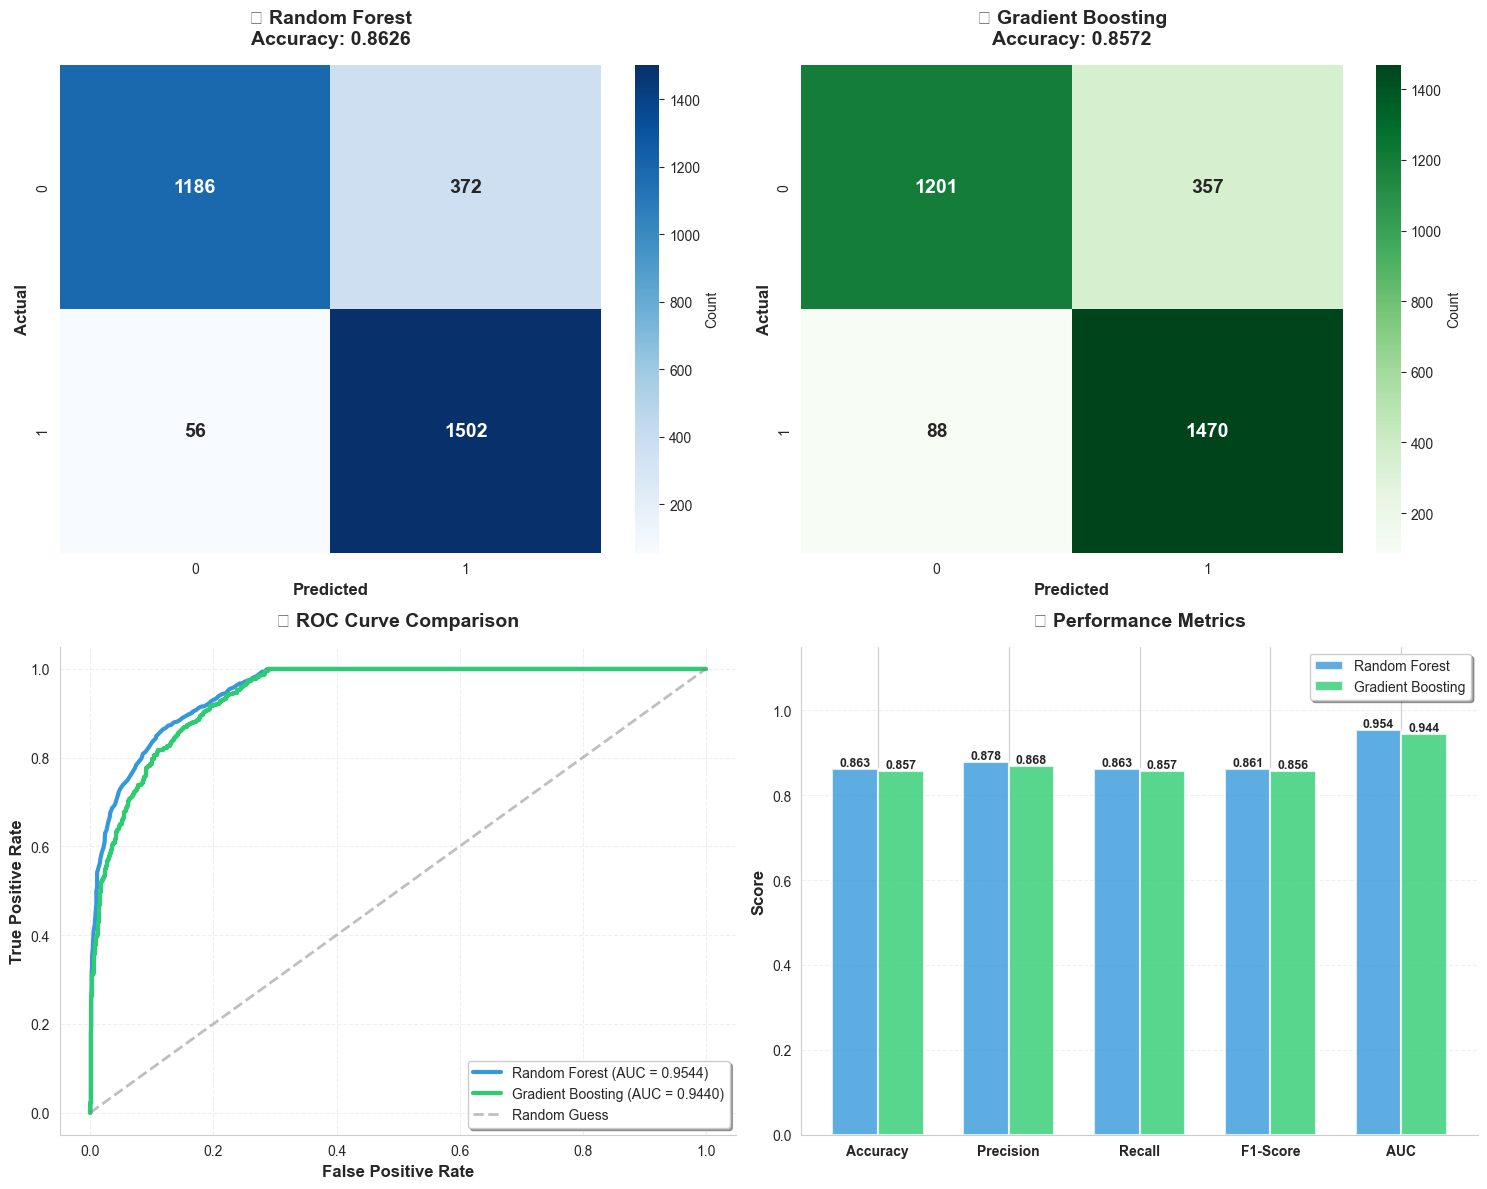

In [9]:
# ===== CELL 9: Model Comparison Visualization =====
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.patch.set_facecolor('white')

# Confusion Matrix - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], 
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14, 'weight': 'bold'})
axes[0, 0].set_title(f'🔵 Random Forest\nAccuracy: {accuracy_score(y_test, y_pred_rf):.4f}', 
                     fontsize=14, fontweight='bold', pad=15)
axes[0, 0].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Predicted', fontsize=12, fontweight='bold')

# Confusion Matrix - Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1],
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14, 'weight': 'bold'})
axes[0, 1].set_title(f'🟢 Gradient Boosting\nAccuracy: {accuracy_score(y_test, y_pred_gb):.4f}', 
                     fontsize=14, fontweight='bold', pad=15)
axes[0, 1].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Predicted', fontsize=12, fontweight='bold')

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

axes[1, 0].plot(fpr_rf, tpr_rf, color='#3498db', lw=3, 
                label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
axes[1, 0].plot(fpr_gb, tpr_gb, color='#2ecc71', lw=3, 
                label=f'Gradient Boosting (AUC = {roc_auc_gb:.4f})')
axes[1, 0].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', 
                label='Random Guess', alpha=0.5)
axes[1, 0].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
axes[1, 0].set_title('📈 ROC Curve Comparison', fontsize=14, fontweight='bold', pad=15)
axes[1, 0].legend(loc="lower right", fontsize=10, frameon=True, shadow=True)
axes[1, 0].grid(alpha=0.3, linestyle='--')
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# Metrics Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)
gb_report = classification_report(y_test, y_pred_gb, output_dict=True)

rf_scores = [
    accuracy_score(y_test, y_pred_rf),
    rf_report['weighted avg']['precision'],
    rf_report['weighted avg']['recall'],
    rf_report['weighted avg']['f1-score'],
    roc_auc_rf
]
gb_scores = [
    accuracy_score(y_test, y_pred_gb),
    gb_report['weighted avg']['precision'],
    gb_report['weighted avg']['recall'],
    gb_report['weighted avg']['f1-score'],
    roc_auc_gb
]

x = np.arange(len(metrics))
width = 0.35

bars1 = axes[1, 1].bar(x - width/2, rf_scores, width, label='Random Forest', 
                       color='#3498db', alpha=0.8, edgecolor='white', linewidth=1.5)
bars2 = axes[1, 1].bar(x + width/2, gb_scores, width, label='Gradient Boosting', 
                       color='#2ecc71', alpha=0.8, edgecolor='white', linewidth=1.5)

axes[1, 1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1, 1].set_title('📊 Performance Metrics', fontsize=14, fontweight='bold', pad=15)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics, fontsize=10, fontweight='bold')
axes[1, 1].legend(fontsize=10, frameon=True, shadow=True)
axes[1, 1].set_ylim([0, 1.15])
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.3f}', ha='center', va='bottom', 
                       fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


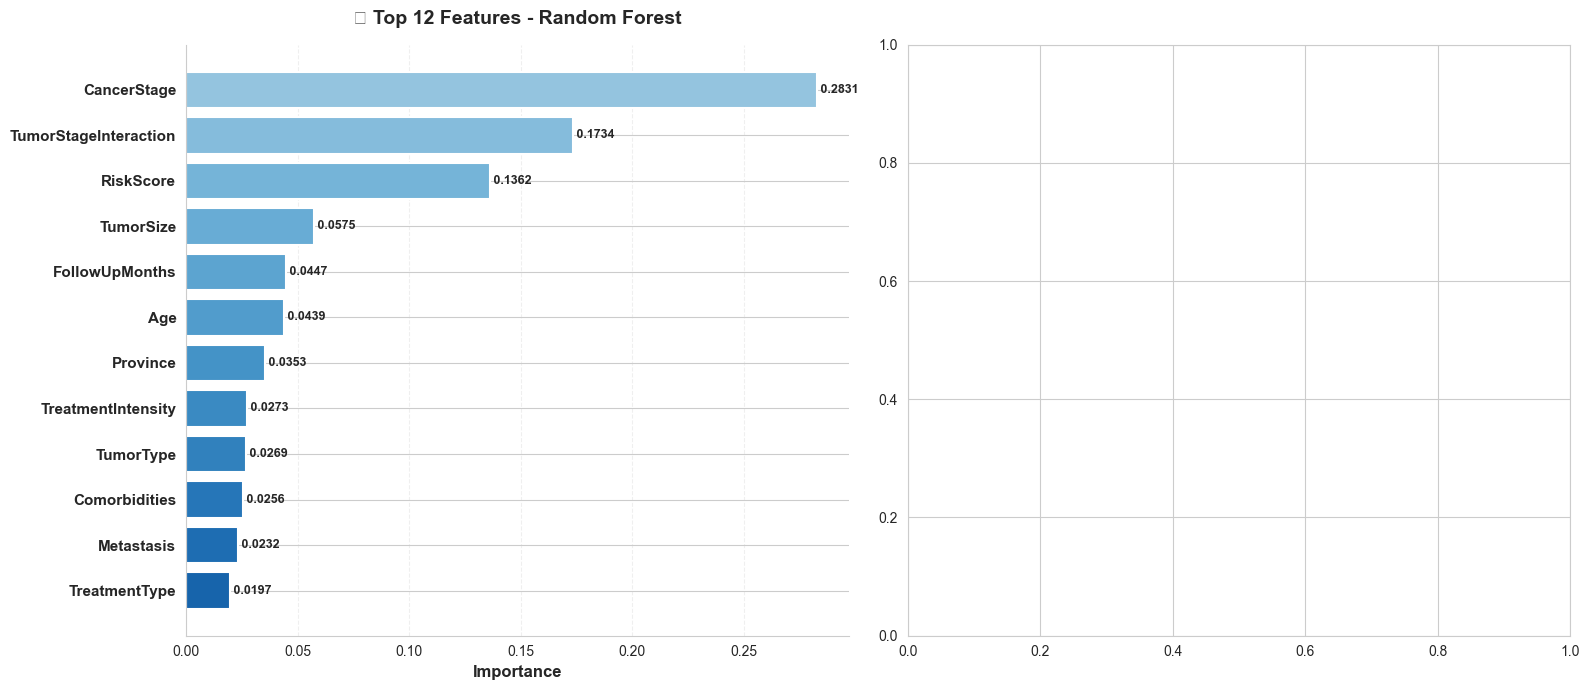

In [12]:
# ===== CELL 10: Feature Importance =====
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

# Random Forest
importances_rf = rf_model.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1][:12]
colors_rf = plt.cm.Blues(np.linspace(0.4, 0.8, len(indices_rf)))

axes[0].barh(range(len(indices_rf)), importances_rf[indices_rf], 
             color=colors_rf, edgecolor='white', linewidth=1.5)
axes[0].set_yticks(range(len(indices_rf)))
axes[0].set_yticklabels(X.columns[indices_rf], fontsize=11, fontweight='bold')
axes[0].set_xlabel('Importance', fontsize=12, fontweight='bold')
axes[0].set_title('🔵 Top 12 Features - Random Forest', fontsize=14, fontweight='bold', pad=15)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Add value labels
for i, idx in enumerate(indices_rf):
    axes[0].text(importances_rf[idx], i, f' {importances_rf[idx]:.4f}', 
                va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


In [13]:
# ===== CELL 11: Final Results =====
print("\n" + "="*80)
print("🎯 FINAL RESULTS")
print("="*80)

print("\n🔵 RANDOM FOREST")
print("-" * 80)
print(classification_report(y_test, y_pred_rf, target_names=['Deceased', 'Alive']))

print("\n🟢 GRADIENT BOOSTING")
print("-" * 80)
print(classification_report(y_test, y_pred_gb, target_names=['Deceased', 'Alive']))

print("\n✅ Analysis Complete!")


🎯 FINAL RESULTS

🔵 RANDOM FOREST
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    Deceased       0.95      0.76      0.85      1558
       Alive       0.80      0.96      0.88      1558

    accuracy                           0.86      3116
   macro avg       0.88      0.86      0.86      3116
weighted avg       0.88      0.86      0.86      3116


🟢 GRADIENT BOOSTING
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    Deceased       0.93      0.77      0.84      1558
       Alive       0.80      0.94      0.87      1558

    accuracy                           0.86      3116
   macro avg       0.87      0.86      0.86      3116
weighted avg       0.87      0.86      0.86      3116


✅ Analysis Complete!


In [1]:
# ===== CELL 1: Import Libraries =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

print("🔬 HỆ THỐNG PHÂN CỤM BỆNH NHÂN UNG THƯ")
print("=" * 80)

🔬 HỆ THỐNG PHÂN CỤM BỆNH NHÂN UNG THƯ


In [2]:
# ===== CELL 2: Load Data =====
df = pd.read_csv('china_cancer_patients_synthetic.csv')

print(f"\n📊 Thông tin dữ liệu:")
print(f"Kích thước: {df.shape[0]} bệnh nhân × {df.shape[1]} biến")
print(f"\nCác biến: {df.columns.tolist()}")
print(f"\nMissing values: {df.isnull().sum().sum()} total")



📊 Thông tin dữ liệu:
Kích thước: 10000 bệnh nhân × 20 biến

Các biến: ['PatientID', 'Gender', 'Age', 'Province', 'Ethnicity', 'TumorType', 'CancerStage', 'DiagnosisDate', 'TumorSize', 'Metastasis', 'TreatmentType', 'SurgeryDate', 'ChemotherapySessions', 'RadiationSessions', 'SurvivalStatus', 'FollowUpMonths', 'SmokingStatus', 'AlcoholUse', 'GeneticMutation', 'Comorbidities']

Missing values: 22509 total


In [3]:
# ===== CELL 3: Feature Engineering =====
df_processed = df.copy()

# Drop unnecessary columns
df_processed = df_processed.drop(columns=['PatientID', 'DiagnosisDate', 'SurgeryDate'], errors='ignore')

# Encode CancerStage
stage_mapping = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 
                 'Stage I': 1, 'Stage II': 2, 'Stage III': 3, 'Stage IV': 4}
if 'CancerStage' in df_processed.columns:
    if df_processed['CancerStage'].dtype == 'object':
        df_processed['CancerStage_Numeric'] = df_processed['CancerStage'].map(stage_mapping)
        df_processed['CancerStage_Numeric'] = df_processed['CancerStage_Numeric'].fillna(
            df_processed['CancerStage_Numeric'].median()
        )
    else:
        df_processed['CancerStage_Numeric'] = df_processed['CancerStage']

# Create composite features
if 'ChemotherapySessions' in df_processed.columns and 'RadiationSessions' in df_processed.columns:
    df_processed['TotalTreatmentSessions'] = (
        df_processed['ChemotherapySessions'] + df_processed['RadiationSessions']
    )

if 'TumorSize' in df_processed.columns and 'CancerStage_Numeric' in df_processed.columns:
    df_processed['SeverityIndex'] = df_processed['TumorSize'] * df_processed['CancerStage_Numeric']

# Encode categorical variables
encoders = {}
categorical_cols = ['TumorType', 'Gender', 'Province', 'Ethnicity', 'Treatment']
for col in categorical_cols:
    if col in df_processed.columns:
        encoders[col] = LabelEncoder()
        df_processed[f'{col}_Encoded'] = encoders[col].fit_transform(df_processed[col].astype(str))

# Encode binary variables
if 'Metastasis' in df_processed.columns:
    df_processed['Metastasis_Binary'] = (df_processed['Metastasis'] == 'Yes').astype(int)

if 'SurvivalStatus' in df_processed.columns:
    df_processed['SurvivalStatus_Binary'] = (df_processed['SurvivalStatus'] == 'Alive').astype(int)

if 'SmokingStatus' in df_processed.columns:
    smoking_map = {'Current': 2, 'Former': 1, 'Never': 0}
    df_processed['SmokingStatus_Encoded'] = df_processed['SmokingStatus'].map(smoking_map).fillna(0).astype(int)

if 'AlcoholUse' in df_processed.columns:
    alcohol_map = {'Heavy': 3, 'Moderate': 2, 'Occasional': 1, 'None': 0}
    df_processed['AlcoholUse_Encoded'] = df_processed['AlcoholUse'].map(alcohol_map).fillna(0).astype(int)

print("\n✅ Feature Engineering hoàn tất!")


✅ Feature Engineering hoàn tất!


In [4]:
# ===== CELL 1: Import Libraries =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

print("🔬 HỆ THỐNG PHÂN CỤM BỆNH NHÂN UNG THƯ")
print("=" * 80)

# ===== CELL 2: Load Data =====
df = pd.read_csv('china_cancer_patients_synthetic.csv')

print(f"\n📊 Thông tin dữ liệu:")
print(f"Kích thước: {df.shape[0]} bệnh nhân × {df.shape[1]} biến")
print(f"\nCác biến: {df.columns.tolist()}")
print(f"\nMissing values: {df.isnull().sum().sum()} total")

# ===== CELL 3: Feature Engineering =====
df_processed = df.copy()

# Drop unnecessary columns
df_processed = df_processed.drop(columns=['PatientID', 'DiagnosisDate', 'SurgeryDate'], errors='ignore')

# Encode CancerStage
stage_mapping = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 
                 'Stage I': 1, 'Stage II': 2, 'Stage III': 3, 'Stage IV': 4}
if 'CancerStage' in df_processed.columns:
    if df_processed['CancerStage'].dtype == 'object':
        df_processed['CancerStage_Numeric'] = df_processed['CancerStage'].map(stage_mapping)
        df_processed['CancerStage_Numeric'] = df_processed['CancerStage_Numeric'].fillna(
            df_processed['CancerStage_Numeric'].median()
        )
    else:
        df_processed['CancerStage_Numeric'] = df_processed['CancerStage']

# Create composite features
if 'ChemotherapySessions' in df_processed.columns and 'RadiationSessions' in df_processed.columns:
    df_processed['TotalTreatmentSessions'] = (
        df_processed['ChemotherapySessions'] + df_processed['RadiationSessions']
    )

if 'TumorSize' in df_processed.columns and 'CancerStage_Numeric' in df_processed.columns:
    df_processed['SeverityIndex'] = df_processed['TumorSize'] * df_processed['CancerStage_Numeric']

# Encode categorical variables
encoders = {}
categorical_cols = ['TumorType', 'Gender', 'Province', 'Ethnicity', 'Treatment']
for col in categorical_cols:
    if col in df_processed.columns:
        encoders[col] = LabelEncoder()
        df_processed[f'{col}_Encoded'] = encoders[col].fit_transform(df_processed[col].astype(str))

# Encode binary variables
if 'Metastasis' in df_processed.columns:
    df_processed['Metastasis_Binary'] = (df_processed['Metastasis'] == 'Yes').astype(int)

if 'SurvivalStatus' in df_processed.columns:
    df_processed['SurvivalStatus_Binary'] = (df_processed['SurvivalStatus'] == 'Alive').astype(int)

if 'SmokingStatus' in df_processed.columns:
    smoking_map = {'Current': 2, 'Former': 1, 'Never': 0}
    df_processed['SmokingStatus_Encoded'] = df_processed['SmokingStatus'].map(smoking_map).fillna(0).astype(int)

if 'AlcoholUse' in df_processed.columns:
    alcohol_map = {'Heavy': 3, 'Moderate': 2, 'Occasional': 1, 'None': 0}
    df_processed['AlcoholUse_Encoded'] = df_processed['AlcoholUse'].map(alcohol_map).fillna(0).astype(int)

print("\n✅ Feature Engineering hoàn tất!")

# ===== CELL 4: Select Features for Clustering =====
potential_features = [
    'Age', 'TumorSize', 'CancerStage_Numeric',
    'ChemotherapySessions', 'RadiationSessions',
    'TotalTreatmentSessions', 'SeverityIndex',
    'Metastasis_Binary', 'TumorType_Encoded',
    'Gender_Encoded', 'SmokingStatus_Encoded',
    'AlcoholUse_Encoded', 'FollowUpMonths',
    'SurvivalStatus_Binary'
]

clustering_features = [f for f in potential_features if f in df_processed.columns]

# Handle missing values
for col in clustering_features:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

print(f"\n📌 Features cho phân cụm ({len(clustering_features)}):")
for i, f in enumerate(clustering_features, 1):
    print(f"   {i}. {f}")

# Create data matrix
X = df_processed[clustering_features].values
print(f"\n✅ Ma trận dữ liệu: {X.shape}")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("✅ Đã chuẩn hóa dữ liệu")

🔬 HỆ THỐNG PHÂN CỤM BỆNH NHÂN UNG THƯ

📊 Thông tin dữ liệu:
Kích thước: 10000 bệnh nhân × 20 biến

Các biến: ['PatientID', 'Gender', 'Age', 'Province', 'Ethnicity', 'TumorType', 'CancerStage', 'DiagnosisDate', 'TumorSize', 'Metastasis', 'TreatmentType', 'SurgeryDate', 'ChemotherapySessions', 'RadiationSessions', 'SurvivalStatus', 'FollowUpMonths', 'SmokingStatus', 'AlcoholUse', 'GeneticMutation', 'Comorbidities']

Missing values: 22509 total

✅ Feature Engineering hoàn tất!

📌 Features cho phân cụm (14):
   1. Age
   2. TumorSize
   3. CancerStage_Numeric
   4. ChemotherapySessions
   5. RadiationSessions
   6. TotalTreatmentSessions
   7. SeverityIndex
   8. Metastasis_Binary
   9. TumorType_Encoded
   10. Gender_Encoded
   11. SmokingStatus_Encoded
   12. AlcoholUse_Encoded
   13. FollowUpMonths
   14. SurvivalStatus_Binary

✅ Ma trận dữ liệu: (10000, 14)
✅ Đã chuẩn hóa dữ liệu


In [5]:
# ===== CELL 5: Dimensionality Reduction =====
print("\n🎨 Giảm chiều dữ liệu...")

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"✅ PCA: {sum(pca.explained_variance_ratio_)*100:.1f}% variance")

# t-SNE
print("🔄 Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print("✅ t-SNE completed!")


🎨 Giảm chiều dữ liệu...
✅ PCA: 34.7% variance
🔄 Running t-SNE...
✅ t-SNE completed!


In [6]:
# ===== CELL 6: Find Optimal K =====
print("\n🔍 Tìm số cụm tối ưu...")

k_range = range(2, 11)
metrics = {
    'inertia': [],
    'silhouette': [],
    'calinski': [],
    'davies_bouldin': []
}

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels_temp = kmeans_temp.fit_predict(X_scaled)
    
    metrics['inertia'].append(kmeans_temp.inertia_)
    metrics['silhouette'].append(silhouette_score(X_scaled, labels_temp))
    metrics['calinski'].append(calinski_harabasz_score(X_scaled, labels_temp))
    metrics['davies_bouldin'].append(davies_bouldin_score(X_scaled, labels_temp))
    print(f"  k={k}: Silhouette={metrics['silhouette'][-1]:.3f}")

# Optimal k
optimal_k = k_range[np.argmax(metrics['silhouette'])]
print(f"\n🎯 Số cụm tối ưu: k = {optimal_k}")
print(f"   Silhouette Score: {max(metrics['silhouette']):.3f}")


🔍 Tìm số cụm tối ưu...
  k=2: Silhouette=0.177
  k=3: Silhouette=0.184
  k=4: Silhouette=0.151
  k=5: Silhouette=0.144
  k=6: Silhouette=0.137
  k=7: Silhouette=0.106
  k=8: Silhouette=0.110
  k=9: Silhouette=0.112
  k=10: Silhouette=0.105

🎯 Số cụm tối ưu: k = 3
   Silhouette Score: 0.184


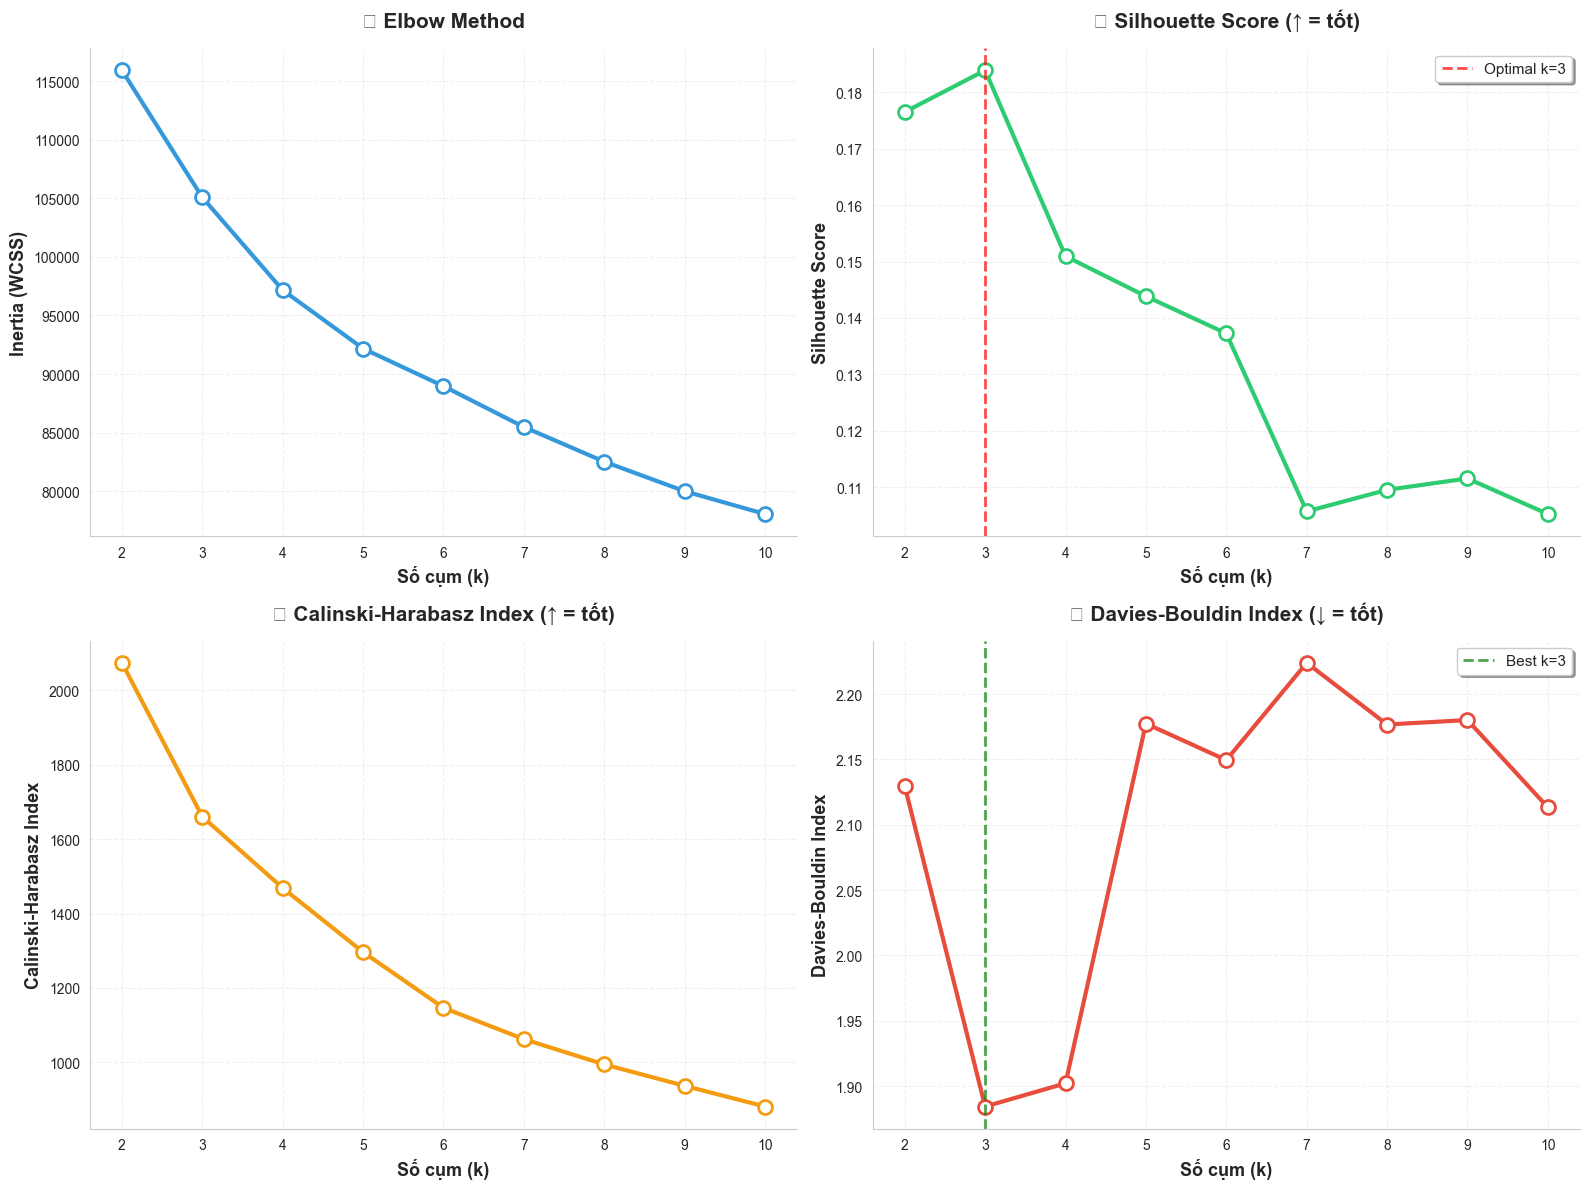

In [7]:
# ===== CELL 7: Evaluation Metrics Visualization =====
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('white')

# Elbow Method
axes[0, 0].plot(k_range, metrics['inertia'], 'o-', linewidth=3, markersize=10, 
                color='#3498db', markerfacecolor='white', markeredgewidth=2)
axes[0, 0].set_xlabel('Số cụm (k)', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Inertia (WCSS)', fontsize=13, fontweight='bold')
axes[0, 0].set_title('📊 Elbow Method', fontsize=15, fontweight='bold', pad=15)
axes[0, 0].grid(True, alpha=0.3, linestyle='--')
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# Silhouette Score
axes[0, 1].plot(k_range, metrics['silhouette'], 'o-', linewidth=3, markersize=10, 
                color='#2ecc71', markerfacecolor='white', markeredgewidth=2)
axes[0, 1].axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, 
                   alpha=0.7, label=f'Optimal k={optimal_k}')
axes[0, 1].set_xlabel('Số cụm (k)', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Silhouette Score', fontsize=13, fontweight='bold')
axes[0, 1].set_title('📊 Silhouette Score (↑ = tốt)', fontsize=15, fontweight='bold', pad=15)
axes[0, 1].grid(True, alpha=0.3, linestyle='--')
axes[0, 1].legend(fontsize=11, frameon=True, shadow=True)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# Calinski-Harabasz Index
axes[1, 0].plot(k_range, metrics['calinski'], 'o-', linewidth=3, markersize=10, 
                color='#f39c12', markerfacecolor='white', markeredgewidth=2)
axes[1, 0].set_xlabel('Số cụm (k)', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Calinski-Harabasz Index', fontsize=13, fontweight='bold')
axes[1, 0].set_title('📊 Calinski-Harabasz Index (↑ = tốt)', fontsize=15, fontweight='bold', pad=15)
axes[1, 0].grid(True, alpha=0.3, linestyle='--')
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# Davies-Bouldin Index
axes[1, 1].plot(k_range, metrics['davies_bouldin'], 'o-', linewidth=3, markersize=10, 
                color='#e74c3c', markerfacecolor='white', markeredgewidth=2)
best_db_k = k_range[np.argmin(metrics['davies_bouldin'])]
axes[1, 1].axvline(x=best_db_k, color='green', linestyle='--', linewidth=2, 
                   alpha=0.7, label=f'Best k={best_db_k}')
axes[1, 1].set_xlabel('Số cụm (k)', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Davies-Bouldin Index', fontsize=13, fontweight='bold')
axes[1, 1].set_title('📊 Davies-Bouldin Index (↓ = tốt)', fontsize=15, fontweight='bold', pad=15)
axes[1, 1].grid(True, alpha=0.3, linestyle='--')
axes[1, 1].legend(fontsize=11, frameon=True, shadow=True)
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [8]:
# ===== CELL 8: Compare Clustering Algorithms =====
print("\n🤖 So sánh các thuật toán phân cụm...")

algorithms = {}

# K-Means
print("1️⃣ K-Means...")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20, max_iter=300)
labels_kmeans = kmeans.fit_predict(X_scaled)
algorithms['K-Means'] = {
    'labels': labels_kmeans,
    'silhouette': silhouette_score(X_scaled, labels_kmeans),
    'calinski': calinski_harabasz_score(X_scaled, labels_kmeans),
    'davies_bouldin': davies_bouldin_score(X_scaled, labels_kmeans)
}

# GMM
print("2️⃣ Gaussian Mixture Model...")
gmm = GaussianMixture(n_components=optimal_k, random_state=42, max_iter=200)
labels_gmm = gmm.fit_predict(X_scaled)
algorithms['GMM'] = {
    'labels': labels_gmm,
    'silhouette': silhouette_score(X_scaled, labels_gmm),
    'calinski': calinski_harabasz_score(X_scaled, labels_gmm),
    'davies_bouldin': davies_bouldin_score(X_scaled, labels_gmm)
}

# Hierarchical
print("3️⃣ Hierarchical Clustering...")
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
labels_hierarchical = hierarchical.fit_predict(X_scaled)
algorithms['Hierarchical'] = {
    'labels': labels_hierarchical,
    'silhouette': silhouette_score(X_scaled, labels_hierarchical),
    'calinski': calinski_harabasz_score(X_scaled, labels_hierarchical),
    'davies_bouldin': davies_bouldin_score(X_scaled, labels_hierarchical)
}

# DBSCAN
print("4️⃣ DBSCAN...")
dbscan = DBSCAN(eps=2.5, min_samples=30)
labels_dbscan = dbscan.fit_predict(X_scaled)
n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)

if n_clusters_dbscan > 1:
    mask = labels_dbscan != -1
    if sum(mask) > 0:
        algorithms['DBSCAN'] = {
            'labels': labels_dbscan,
            'silhouette': silhouette_score(X_scaled[mask], labels_dbscan[mask]),
            'calinski': calinski_harabasz_score(X_scaled[mask], labels_dbscan[mask]),
            'davies_bouldin': davies_bouldin_score(X_scaled[mask], labels_dbscan[mask])
        }

# Display comparison
print("\n📊 Bảng so sánh:")
for algo_name, algo_info in algorithms.items():
    print(f"{algo_name:15} | Silhouette: {algo_info['silhouette']:.3f} | "
          f"Calinski: {algo_info['calinski']:.1f} | Davies-Bouldin: {algo_info['davies_bouldin']:.3f}")

# Select best algorithm
best_algo = max(algorithms.items(), key=lambda x: x[1]['silhouette'])[0]
print(f"\n🏆 Thuật toán tốt nhất: {best_algo} (Silhouette: {algorithms[best_algo]['silhouette']:.3f})")

best_labels = algorithms[best_algo]['labels']
df_processed['Cluster'] = best_labels

# Remove outliers if DBSCAN
if best_algo == 'DBSCAN':
    df_processed = df_processed[df_processed['Cluster'] != -1].copy()
    best_labels = df_processed['Cluster'].values



🤖 So sánh các thuật toán phân cụm...
1️⃣ K-Means...
2️⃣ Gaussian Mixture Model...
3️⃣ Hierarchical Clustering...
4️⃣ DBSCAN...

📊 Bảng so sánh:
K-Means         | Silhouette: 0.184 | Calinski: 1660.4 | Davies-Bouldin: 1.884
GMM             | Silhouette: 0.147 | Calinski: 1299.9 | Davies-Bouldin: 2.240
Hierarchical    | Silhouette: 0.160 | Calinski: 1421.6 | Davies-Bouldin: 2.068

🏆 Thuật toán tốt nhất: K-Means (Silhouette: 0.184)


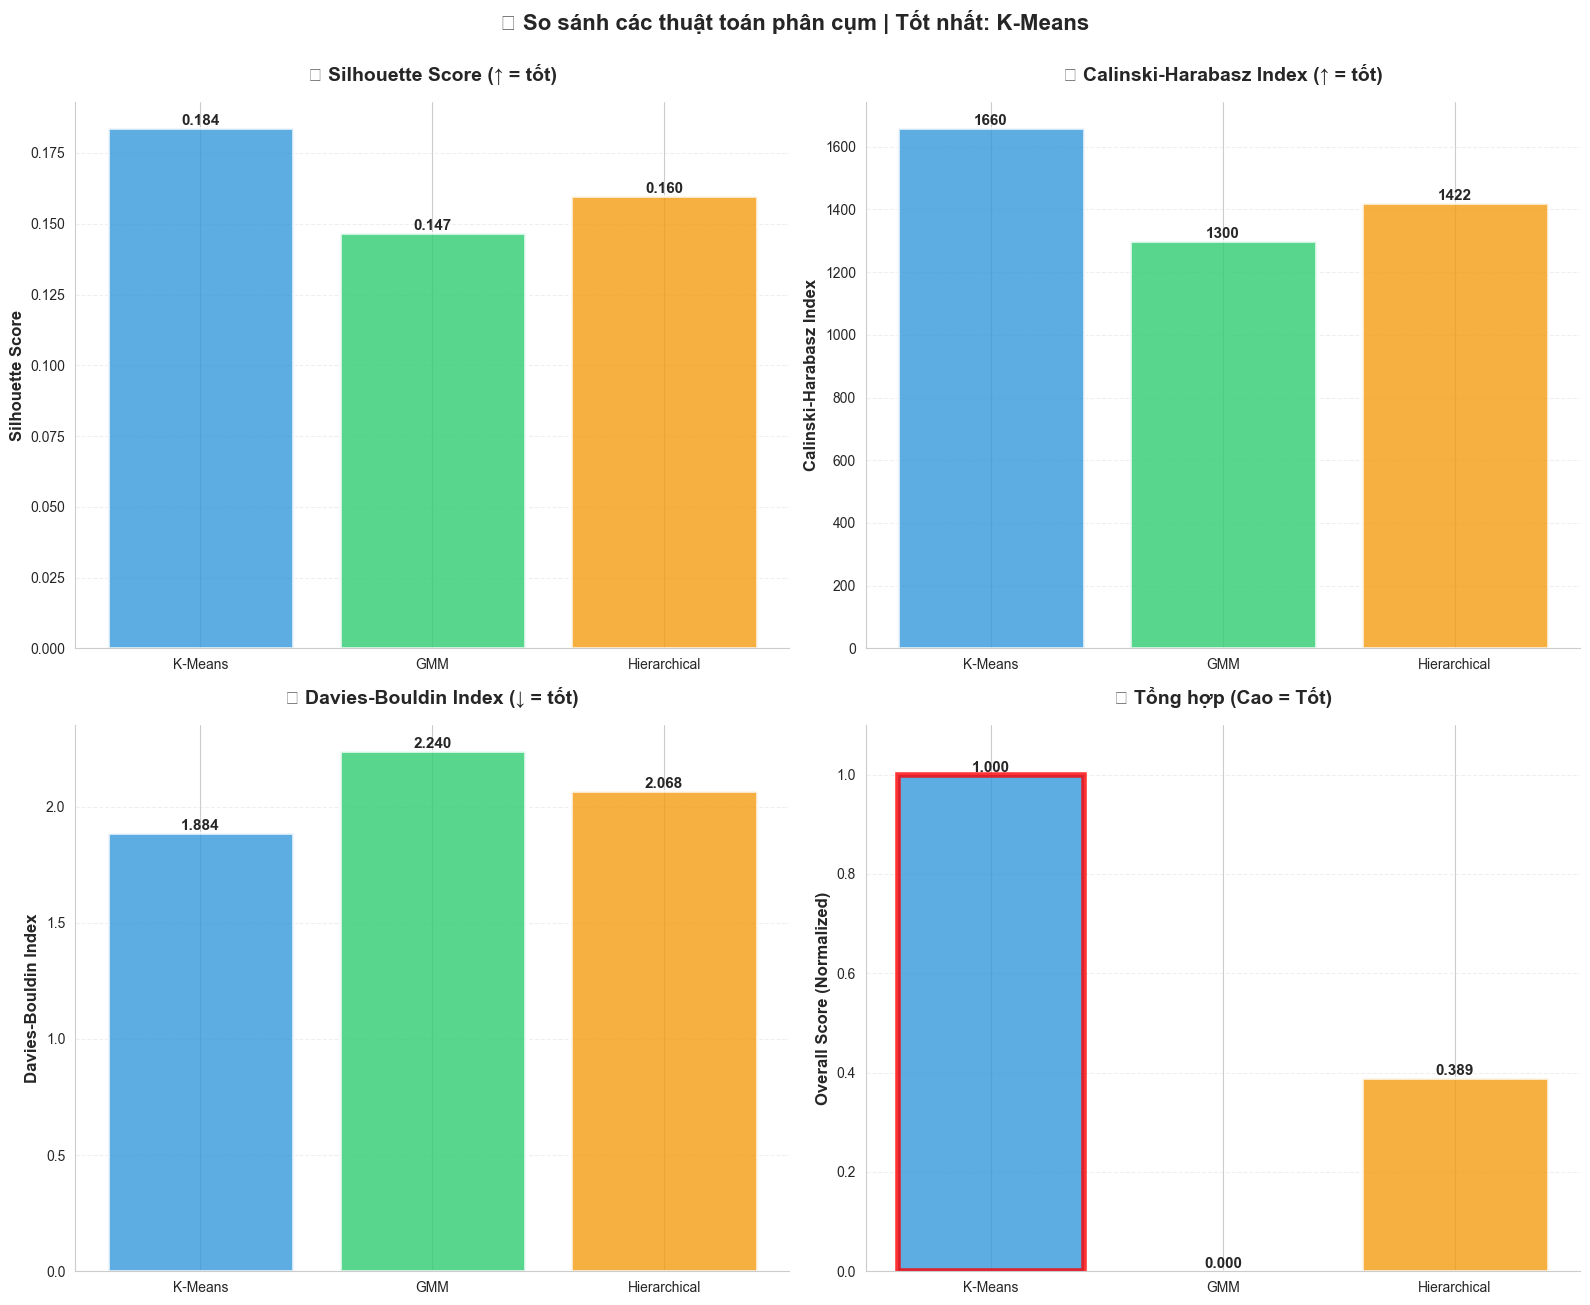

In [9]:
# ===== CELL 9: Algorithm Comparison Visualization =====
fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.patch.set_facecolor('white')

algo_names = list(algorithms.keys())
algo_colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

# Silhouette Scores
sil_scores = [algorithms[algo]['silhouette'] for algo in algo_names]
bars1 = axes[0, 0].bar(algo_names, sil_scores, color=algo_colors[:len(algo_names)], 
                       alpha=0.8, edgecolor='white', linewidth=2)
axes[0, 0].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[0, 0].set_title('🏆 Silhouette Score (↑ = tốt)', fontsize=14, fontweight='bold', pad=15)
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)
for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Calinski-Harabasz Index
cal_scores = [algorithms[algo]['calinski'] for algo in algo_names]
bars2 = axes[0, 1].bar(algo_names, cal_scores, color=algo_colors[:len(algo_names)], 
                       alpha=0.8, edgecolor='white', linewidth=2)
axes[0, 1].set_ylabel('Calinski-Harabasz Index', fontsize=12, fontweight='bold')
axes[0, 1].set_title('🏆 Calinski-Harabasz Index (↑ = tốt)', fontsize=14, fontweight='bold', pad=15)
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)
for bar in bars2:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Davies-Bouldin Index
db_scores = [algorithms[algo]['davies_bouldin'] for algo in algo_names]
bars3 = axes[1, 0].bar(algo_names, db_scores, color=algo_colors[:len(algo_names)], 
                       alpha=0.8, edgecolor='white', linewidth=2)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=12, fontweight='bold')
axes[1, 0].set_title('🏆 Davies-Bouldin Index (↓ = tốt)', fontsize=14, fontweight='bold', pad=15)
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)
for bar in bars3:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Overall Score Comparison (Normalized)
sil_norm = (np.array(sil_scores) - min(sil_scores)) / (max(sil_scores) - min(sil_scores)) if max(sil_scores) != min(sil_scores) else np.ones(len(sil_scores))
cal_norm = (np.array(cal_scores) - min(cal_scores)) / (max(cal_scores) - min(cal_scores)) if max(cal_scores) != min(cal_scores) else np.ones(len(cal_scores))
db_norm = 1 - (np.array(db_scores) - min(db_scores)) / (max(db_scores) - min(db_scores)) if max(db_scores) != min(db_scores) else np.ones(len(db_scores))
overall = (sil_norm + cal_norm + db_norm) / 3

bars4 = axes[1, 1].bar(algo_names, overall, color=algo_colors[:len(algo_names)], 
                       alpha=0.8, edgecolor='white', linewidth=2)
axes[1, 1].set_ylabel('Overall Score (Normalized)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('🏆 Tổng hợp (Cao = Tốt)', fontsize=14, fontweight='bold', pad=15)
axes[1, 1].set_ylim([0, 1.1])
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

# Highlight best
best_idx = algo_names.index(best_algo)
bars4[best_idx].set_edgecolor('red')
bars4[best_idx].set_linewidth(4)

for bar in bars4:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle(f'📊 So sánh các thuật toán phân cụm | Tốt nhất: {best_algo}', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

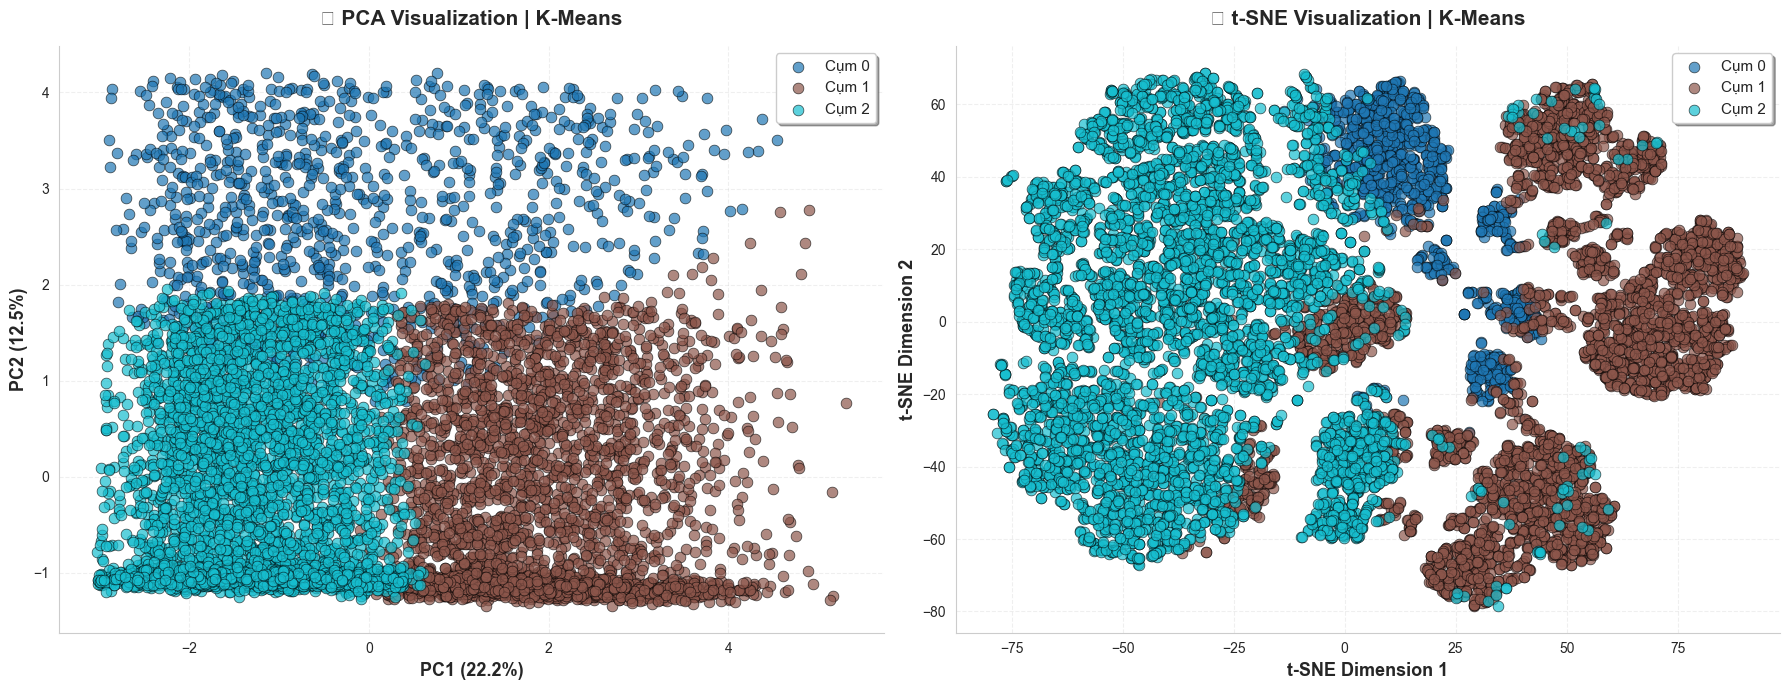

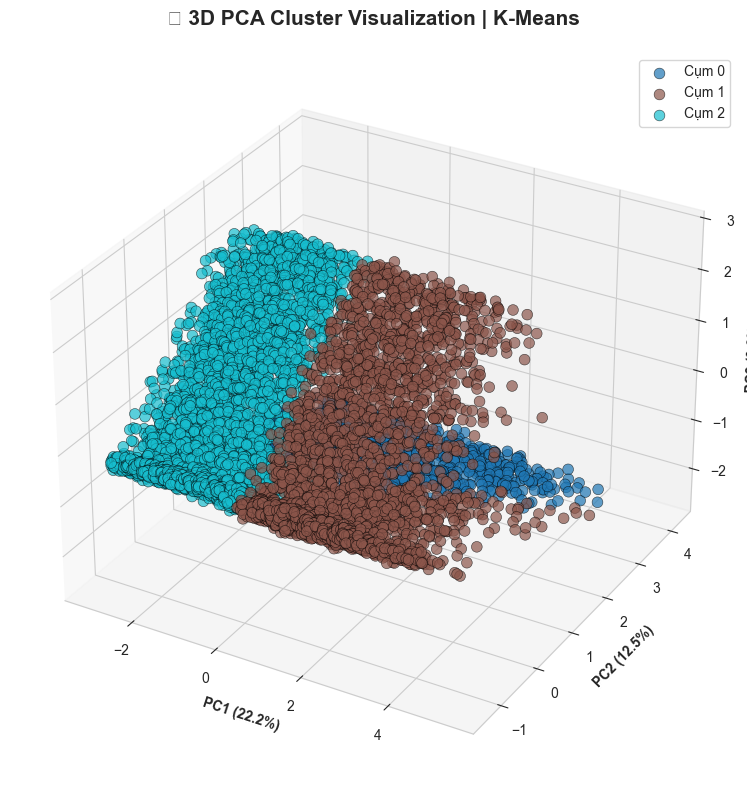

In [10]:
# ===== CELL 10: Cluster Visualization (PCA & t-SNE) =====
if best_algo == 'DBSCAN' and -1 in algorithms['DBSCAN']['labels']:
    mask = algorithms['DBSCAN']['labels'] != -1
    X_pca_plot = X_pca[mask]
    X_tsne_plot = X_tsne[mask]
else:
    X_pca_plot = X_pca
    X_tsne_plot = X_tsne

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('white')

n_clusters_plot = len(np.unique(best_labels))
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters_plot))

# PCA
for cluster_id in np.unique(best_labels):
    mask = best_labels == cluster_id
    axes[0].scatter(X_pca_plot[mask, 0], X_pca_plot[mask, 1], 
                   c=[colors[int(cluster_id)]], label=f'Cụm {cluster_id}',
                   s=60, alpha=0.7, edgecolors='black', linewidth=0.5)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
                  fontsize=13, fontweight='bold')
axes[0].set_title(f'📍 PCA Visualization | {best_algo}', fontsize=15, fontweight='bold', pad=15)
axes[0].legend(loc='best', fontsize=11, frameon=True, shadow=True)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# t-SNE
for cluster_id in np.unique(best_labels):
    mask = best_labels == cluster_id
    axes[1].scatter(X_tsne_plot[mask, 0], X_tsne_plot[mask, 1], 
                   c=[colors[int(cluster_id)]], label=f'Cụm {cluster_id}',
                   s=60, alpha=0.7, edgecolors='black', linewidth=0.5)

axes[1].set_xlabel('t-SNE Dimension 1', fontsize=13, fontweight='bold')
axes[1].set_ylabel('t-SNE Dimension 2', fontsize=13, fontweight='bold')
axes[1].set_title(f'📍 t-SNE Visualization | {best_algo}', fontsize=15, fontweight='bold', pad=15)
axes[1].legend(loc='best', fontsize=11, frameon=True, shadow=True)
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
# ===== CELL 11: 3D Cluster Visualization (PCA 3D) =====
from mpl_toolkits.mplot3d import Axes3D

# PCA 3D
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
fig.patch.set_facecolor('white')

n_clusters_3d = len(np.unique(best_labels))
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters_3d))

for cluster_id in np.unique(best_labels):
    mask = best_labels == cluster_id
    ax.scatter(
        X_pca_3d[mask, 0],
        X_pca_3d[mask, 1],
        X_pca_3d[mask, 2],
        c=[colors[int(cluster_id)]],
        label=f'Cụm {cluster_id}',
        s=60,
        alpha=0.7,
        edgecolors='black',
        linewidth=0.4
    )

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)', fontweight='bold')

ax.set_title(f'📍 3D PCA Cluster Visualization | {best_algo}', fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='best')
plt.tight_layout()
plt.show()


In [11]:
# ===== CELL 11: Cluster Statistics =====
print("\n📋 Phân tích chi tiết các cụm:")
print("=" * 80)

analysis_features = []
for feat in ['Age', 'TumorSize', 'CancerStage_Numeric', 'ChemotherapySessions', 
             'RadiationSessions', 'TotalTreatmentSessions', 'SeverityIndex', 'FollowUpMonths']:
    if feat in df_processed.columns:
        analysis_features.append(feat)

for cluster_id in sorted(df_processed['Cluster'].unique()):
    cluster_data = df_processed[df_processed['Cluster'] == cluster_id]
    n_patients = len(cluster_data)
    pct = (n_patients / len(df_processed)) * 100
    
    print(f"\n🔹 CỤM {cluster_id} - {n_patients} bệnh nhân ({pct:.1f}%)")
    print("-" * 80)
    
    for feat in analysis_features[:9]:  # Top 6 features
        if feat in cluster_data.columns:
            mean_val = cluster_data[feat].mean()
            std_val = cluster_data[feat].std()
            print(f"   • {feat}: {mean_val:.2f} ± {std_val:.2f}")
    
    if 'Metastasis_Binary' in cluster_data.columns:
        metastasis_rate = cluster_data['Metastasis_Binary'].mean() * 100
        print(f"   • Tỷ lệ di căn: {metastasis_rate:.1f}%")
    
    if 'SurvivalStatus_Binary' in cluster_data.columns:
        survival_rate = cluster_data['SurvivalStatus_Binary'].mean() * 100
        print(f"   • Tỷ lệ sống sót: {survival_rate:.1f}%")



📋 Phân tích chi tiết các cụm:

🔹 CỤM 0 - 1109 bệnh nhân (11.1%)
--------------------------------------------------------------------------------
   • Age: 51.10 ± 19.56
   • TumorSize: 6.30 ± 2.16
   • CancerStage_Numeric: 2.28 ± 0.98
   • ChemotherapySessions: 0.00 ± 0.00
   • RadiationSessions: 21.98 ± 5.15
   • TotalTreatmentSessions: 21.98 ± 5.15
   • SeverityIndex: 15.20 ± 9.56
   • FollowUpMonths: 30.60 ± 17.12
   • Tỷ lệ di căn: 23.7%
   • Tỷ lệ sống sót: 80.9%

🔹 CỤM 1 - 3637 bệnh nhân (36.4%)
--------------------------------------------------------------------------------
   • Age: 51.85 ± 19.73
   • TumorSize: 7.60 ± 1.94
   • CancerStage_Numeric: 3.38 ± 0.49
   • ChemotherapySessions: 4.50 ± 6.43
   • RadiationSessions: 0.86 ± 2.96
   • TotalTreatmentSessions: 5.36 ± 6.51
   • SeverityIndex: 25.85 ± 8.16
   • FollowUpMonths: 30.35 ± 17.27
   • Tỷ lệ di căn: 65.8%
   • Tỷ lệ sống sót: 46.0%

🔹 CỤM 2 - 5254 bệnh nhân (52.5%)
---------------------------------------------------

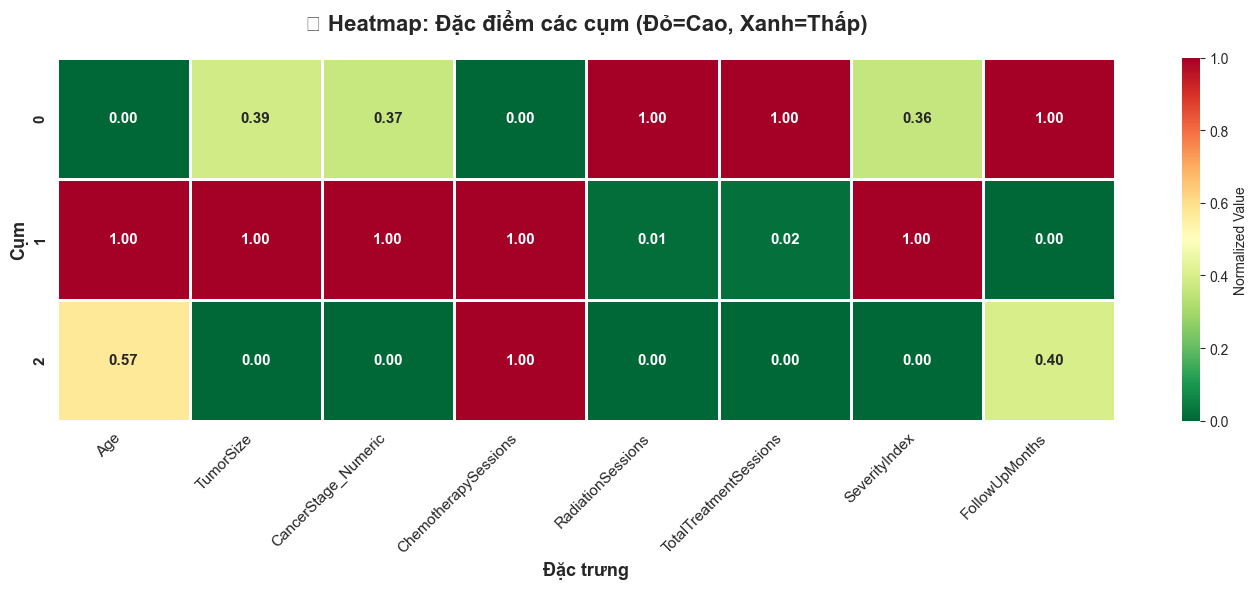

In [12]:
# ===== CELL 12: Heatmap Comparison =====
plt.figure(figsize=(14, max(6, len(np.unique(best_labels)) * 1)))
heatmap_data = df_processed.groupby('Cluster')[analysis_features].mean()
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

sns.heatmap(heatmap_norm, annot=True, cmap='RdYlGn_r', fmt='.2f', 
            linewidths=2, cbar_kws={'label': 'Normalized Value'}, 
            annot_kws={'size': 11, 'weight': 'bold'})
plt.title('🔥 Heatmap: Đặc điểm các cụm (Đỏ=Cao, Xanh=Thấp)', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Cụm', fontsize=13, fontweight='bold')
plt.xlabel('Đặc trưng', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

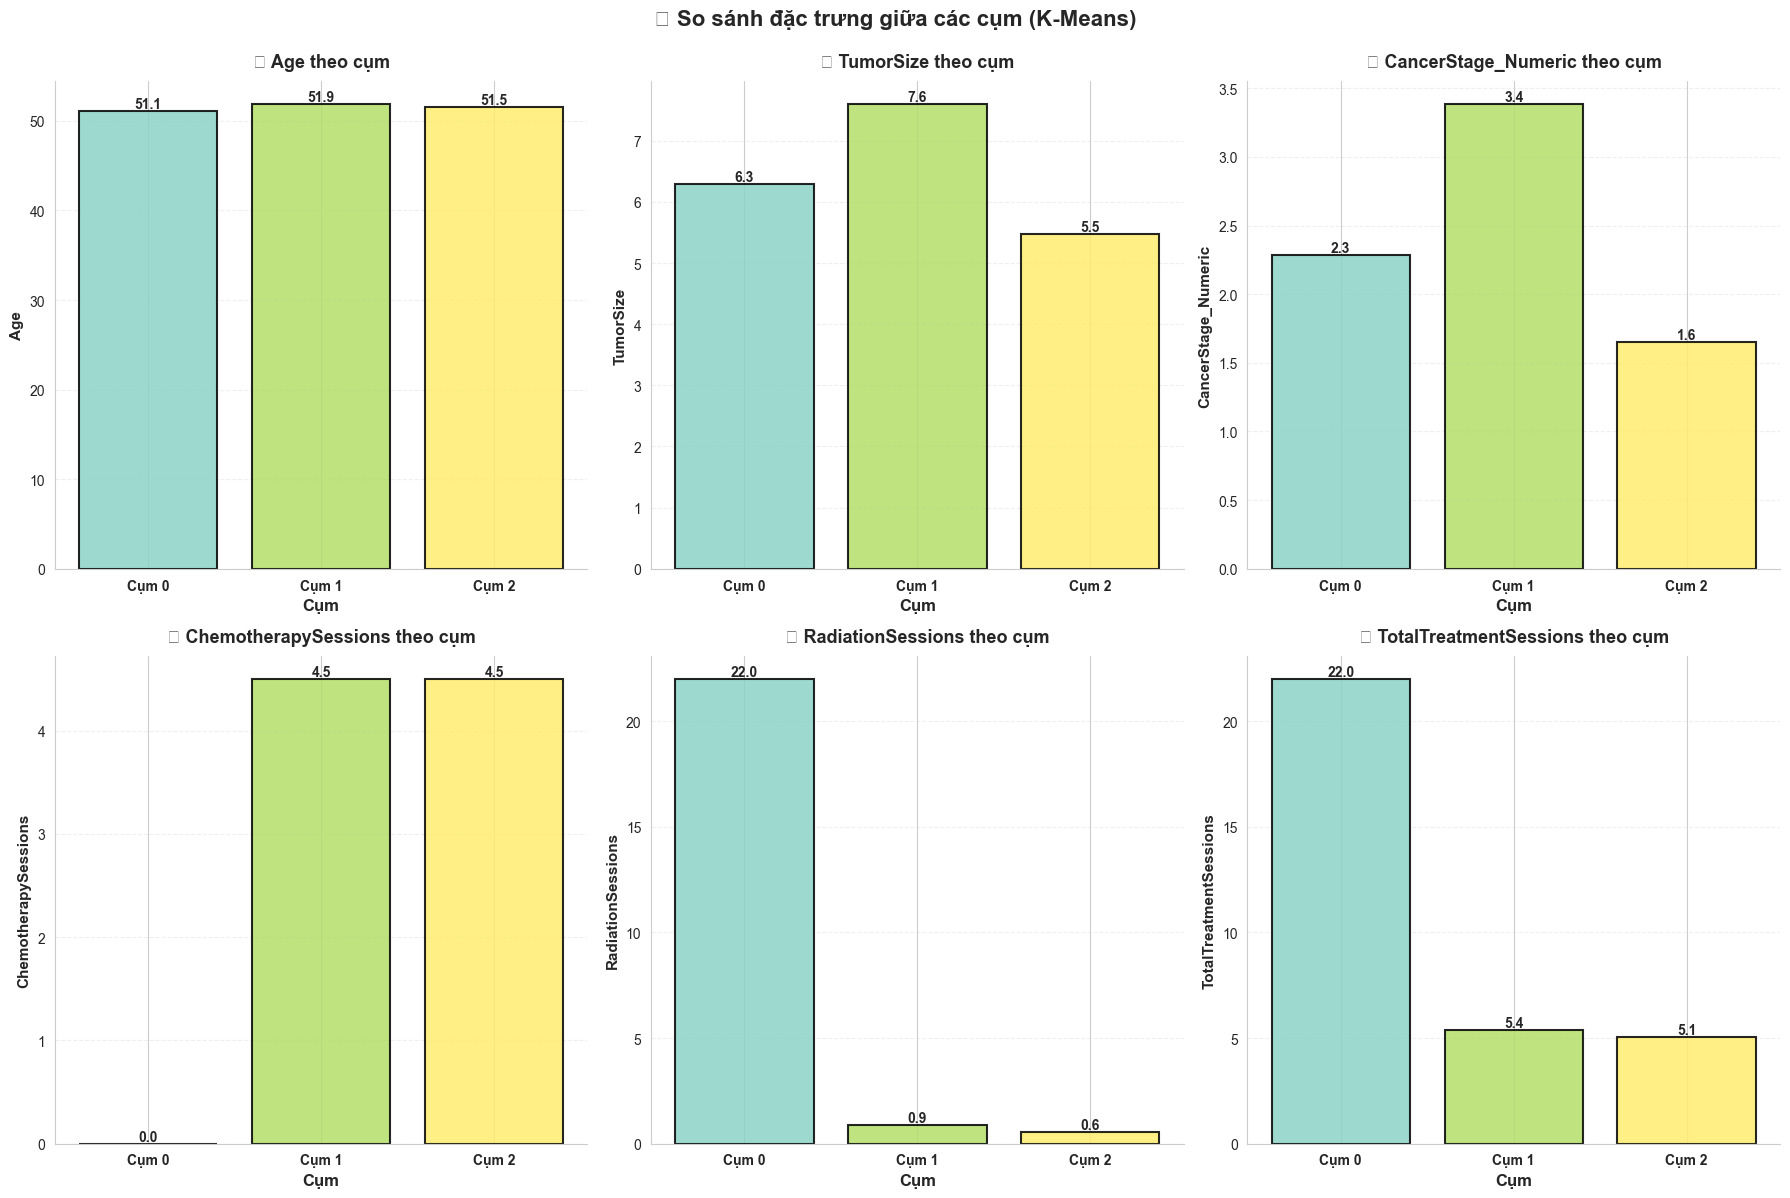

In [13]:
# ===== CELL 13: Cluster Feature Comparison (Bar Charts) =====
n_features = min(6, len(analysis_features))
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.patch.set_facecolor('white')
axes = axes.flatten()

cluster_ids = sorted(df_processed['Cluster'].unique())
n_clusters = len(cluster_ids)
colors_bar = plt.cm.Set3(np.linspace(0, 1, n_clusters))

for idx, feature in enumerate(analysis_features[:n_features]):
    cluster_means = df_processed.groupby('Cluster')[feature].mean().sort_index()
    
    bars = axes[idx].bar(range(len(cluster_means)), cluster_means.values, 
                        color=colors_bar, edgecolor='black', linewidth=1.5, alpha=0.85)
    
    axes[idx].set_xlabel('Cụm', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(feature, fontsize=11, fontweight='bold')
    axes[idx].set_title(f'📊 {feature} theo cụm', fontsize=13, fontweight='bold', pad=10)
    axes[idx].set_xticks(range(len(cluster_means)))
    axes[idx].set_xticklabels([f'Cụm {i}' for i in cluster_means.index], 
                              fontsize=10, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:.1f}', ha='center', va='bottom', 
                      fontweight='bold', fontsize=10)

plt.suptitle(f'📊 So sánh đặc trưng giữa các cụm ({best_algo})', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

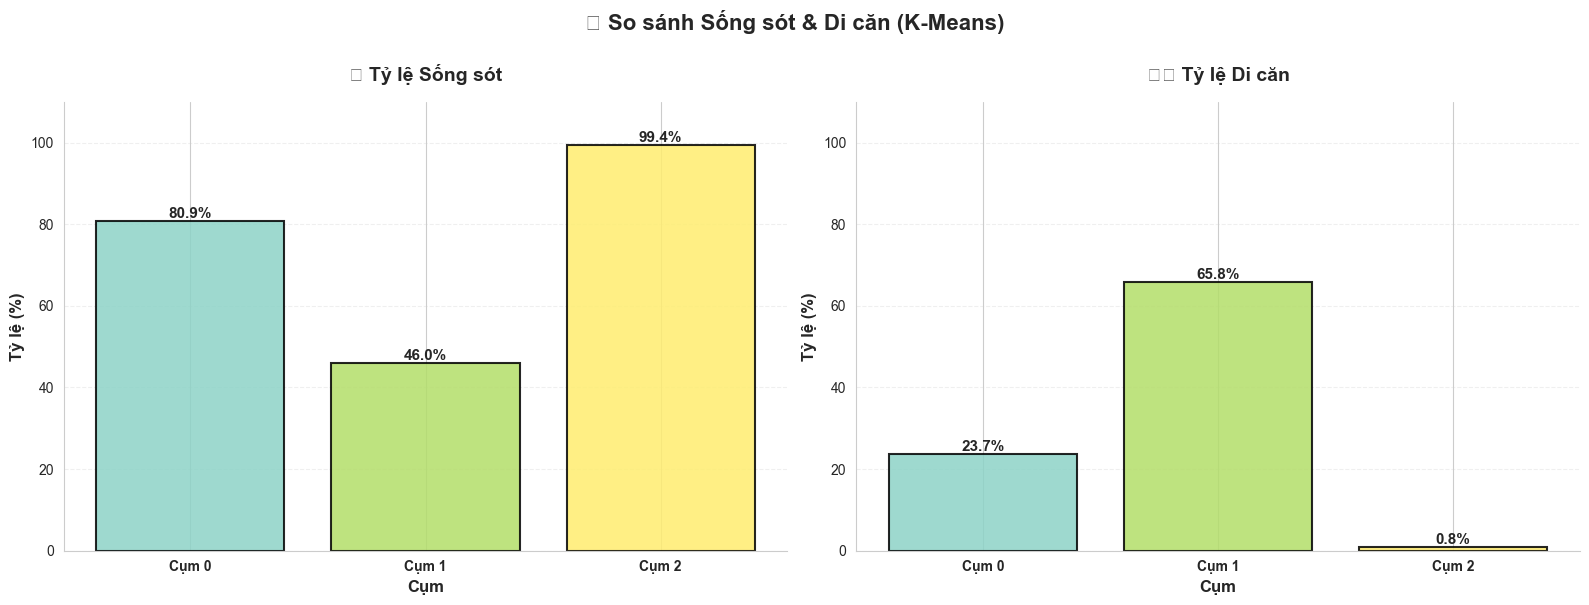

In [14]:
# ===== CELL 15: Survival & Metastasis Comparison =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# Survival Rate
if 'SurvivalStatus_Binary' in df_processed.columns:
    survival_rates = df_processed.groupby('Cluster')['SurvivalStatus_Binary'].mean() * 100
    bars1 = axes[0].bar(range(len(survival_rates)), survival_rates.values,
                        color=colors_bar, edgecolor='black', linewidth=1.5, alpha=0.85)
    axes[0].set_xlabel('Cụm', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Tỷ lệ (%)', fontsize=12, fontweight='bold')
    axes[0].set_title('💚 Tỷ lệ Sống sót', fontsize=14, fontweight='bold', pad=15)
    axes[0].set_xticks(range(len(survival_rates)))
    axes[0].set_xticklabels([f'Cụm {i}' for i in survival_rates.index], fontweight='bold')
    axes[0].set_ylim([0, 110])
    axes[0].grid(axis='y', alpha=0.3, linestyle='--')
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Metastasis Rate
if 'Metastasis_Binary' in df_processed.columns:
    metastasis_rates = df_processed.groupby('Cluster')['Metastasis_Binary'].mean() * 100
    bars2 = axes[1].bar(range(len(metastasis_rates)), metastasis_rates.values,
                        color=colors_bar, edgecolor='black', linewidth=1.5, alpha=0.85)
    axes[1].set_xlabel('Cụm', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Tỷ lệ (%)', fontsize=12, fontweight='bold')
    axes[1].set_title('⚠️ Tỷ lệ Di căn', fontsize=14, fontweight='bold', pad=15)
    axes[1].set_xticks(range(len(metastasis_rates)))
    axes[1].set_xticklabels([f'Cụm {i}' for i in metastasis_rates.index], fontweight='bold')
    axes[1].set_ylim([0, 110])
    axes[1].grid(axis='y', alpha=0.3, linestyle='--')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle(f'📊 So sánh Sống sót & Di căn ({best_algo})', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

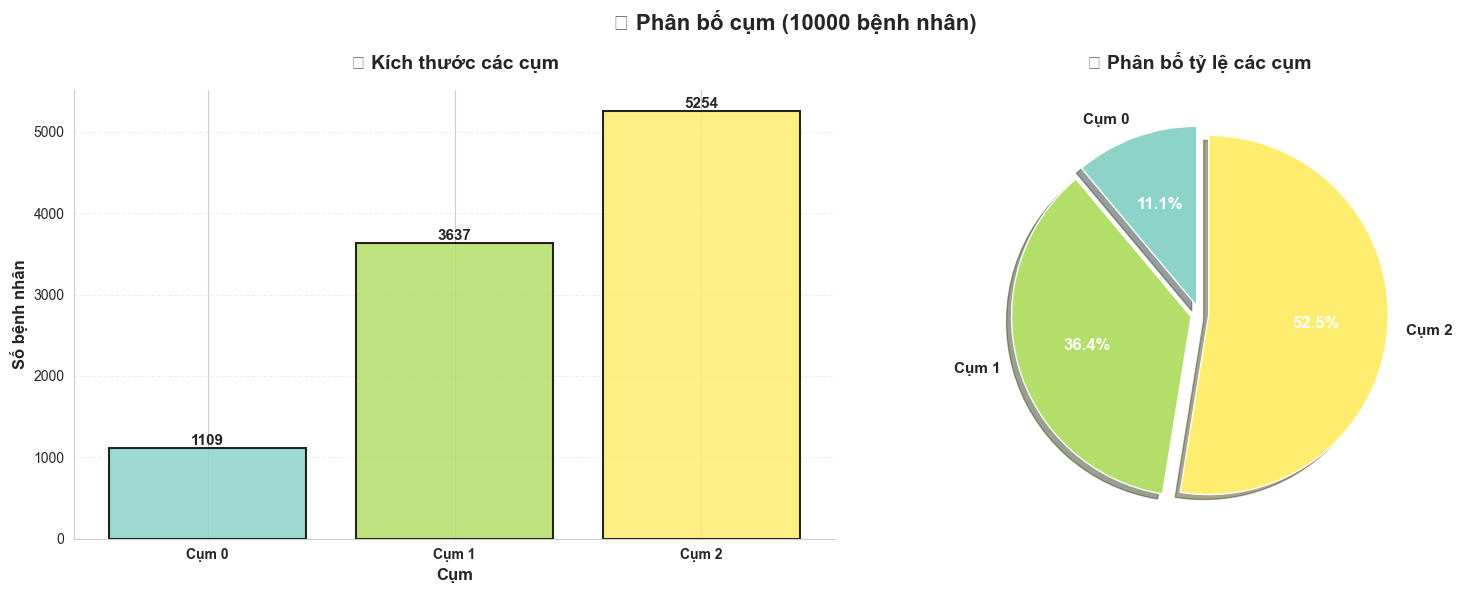

In [15]:
# ===== CELL 16: Cluster Size Distribution =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# Bar chart
cluster_sizes = df_processed['Cluster'].value_counts().sort_index()
bars = axes[0].bar(range(len(cluster_sizes)), cluster_sizes.values,
                   color=colors_bar, edgecolor='black', linewidth=1.5, alpha=0.85)
axes[0].set_xlabel('Cụm', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Số bệnh nhân', fontsize=12, fontweight='bold')
axes[0].set_title('👥 Kích thước các cụm', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xticks(range(len(cluster_sizes)))
axes[0].set_xticklabels([f'Cụm {i}' for i in cluster_sizes.index], fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Pie chart
cluster_pcts = (cluster_sizes / cluster_sizes.sum() * 100).values
explode = [0.05] * len(cluster_pcts)
wedges, texts, autotexts = axes[1].pie(cluster_pcts, labels=[f'Cụm {i}' for i in cluster_sizes.index],
                                         autopct='%1.1f%%', colors=colors_bar, startangle=90,
                                         explode=explode, shadow=True, 
                                         textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('📊 Phân bố tỷ lệ các cụm', fontsize=14, fontweight='bold', pad=15)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

plt.suptitle(f'👥 Phân bố cụm ({len(df_processed)} bệnh nhân)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [16]:
# ===== CELL 17: Final Summary =====
print("\n" + "=" * 80)
print("✅ HOÀN THÀNH PHÂN TÍCH PHÂN CỤM!")
print("=" * 80)

print(f"\n📊 TỔNG KẾT:")
print(f"   • Dataset: {len(df_processed)} bệnh nhân")
print(f"   • Features sử dụng: {len(clustering_features)}")
print(f"   • Thuật toán tốt nhất: {best_algo}")
print(f"   • Số cụm: {len(np.unique(best_labels))}")
print(f"   • Silhouette Score: {algorithms[best_algo]['silhouette']:.3f}")
print(f"   • Calinski-Harabasz: {algorithms[best_algo]['calinski']:.1f}")
print(f"   • Davies-Bouldin: {algorithms[best_algo]['davies_bouldin']:.3f}")

print(f"\n💾 Lưu kết quả:")
output_file = 'cancer_clustering_results.csv'
df_processed.to_csv(output_file, index=False)
print(f"   ✅ Đã lưu: {output_file}")

print("\n🎉 Analysis Complete!")


✅ HOÀN THÀNH PHÂN TÍCH PHÂN CỤM!

📊 TỔNG KẾT:
   • Dataset: 10000 bệnh nhân
   • Features sử dụng: 14
   • Thuật toán tốt nhất: K-Means
   • Số cụm: 3
   • Silhouette Score: 0.184
   • Calinski-Harabasz: 1660.4
   • Davies-Bouldin: 1.884

💾 Lưu kết quả:
   ✅ Đã lưu: cancer_clustering_results.csv

🎉 Analysis Complete!
